# Analysis of the candidate features

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    fbeta_score,
)

sys.path.append(str(Path.cwd().parent))
from df_wrapper import CandidateFrame

plt.rcParams.update(
    {
        "font.size": 14,  # base size (ticks, legend text default to this)
        "axes.labelsize": 14,  # xlabel/ylabel
        "axes.titlesize": 16,  # title
        "legend.fontsize": 14,
    }
)

linking_dir = Path("../data/candidate_linking")
experiment_dir = Path("../data/experiments")
cfg = toml.load("../config.toml")

# combined_candidates is the dragnet of all candidate particles across experiments
candidate_frame = CandidateFrame(experiment_dir, "combined_candidates.csv")
print(f"Number of candidate particles: {candidate_frame.length}")

# instance_to_cluster maps candidates into clusters that represent the same particle across different experiments
df_instance_to_cluster = pd.read_csv(linking_dir / "instance_to_cluster.csv")
print(f"Number of instance to cluster mappings: {len(df_instance_to_cluster)}")

# clusters represents the clusters into which unique particles map. It contains the number of instances of the particle across different experiments, tracks the number of candidates associated with the cluster, the list of slab thicknesses for which they were detected, the labeling status, whether the labels are consistent (no labeling conflicts) and the maximum number of voxels associated with the cluster.

/Users/jim/Documents/GitHub/particles/df_wrapper.py:43: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  if not self.date_path.exists():


Number of candidate particles: 501066
Number of instance to cluster mappings: 501066


# Break down classifications

In [ ]:
df_valid_slabs = candidate_frame.df[candidate_frame.df["slab_thickness"].isin([21,26,25])]
df_classified = df_valid_slabs[df_valid_slabs["particle"].isin([0,1,2,3,4])]
df_TP = df_classified[df_classified["particle"].isin([1,2,3])]
df_FP = df_classified[df_classified["particle"].isin([0])]
df_indeterminate = df_classified[df_classified["particle"].isin([4])]
print("Classified:", len(df_classified))
print("True Positives:", len(df_TP))
print("False Positives:", len(df_FP))
print("Indeterminate:", len(df_indeterminate))

total_inspected = len(df_classified)
print("Total Inspected:", total_inspected, total_inspected/len(df_valid_slabs))

cf_TP = CandidateFrame(dataFrame = df_TP)
cf_FP = CandidateFrame(df_FP)
cf_indeterminate = CandidateFrame(df_indeterminate)

Classified: 11525
True Positives: 4128
False Positives: 5083
Indeterminate: 2314
Total Inspected: 11525 0.0931410976506623


AttributeError: 'DataFrame' object has no attribute 'is_dir'

# Distribution of SNR Peak
The SNR peak threshold of 4.2 is used for seeding, so a cluster at the smaller end could indicate reduction in sensitivity

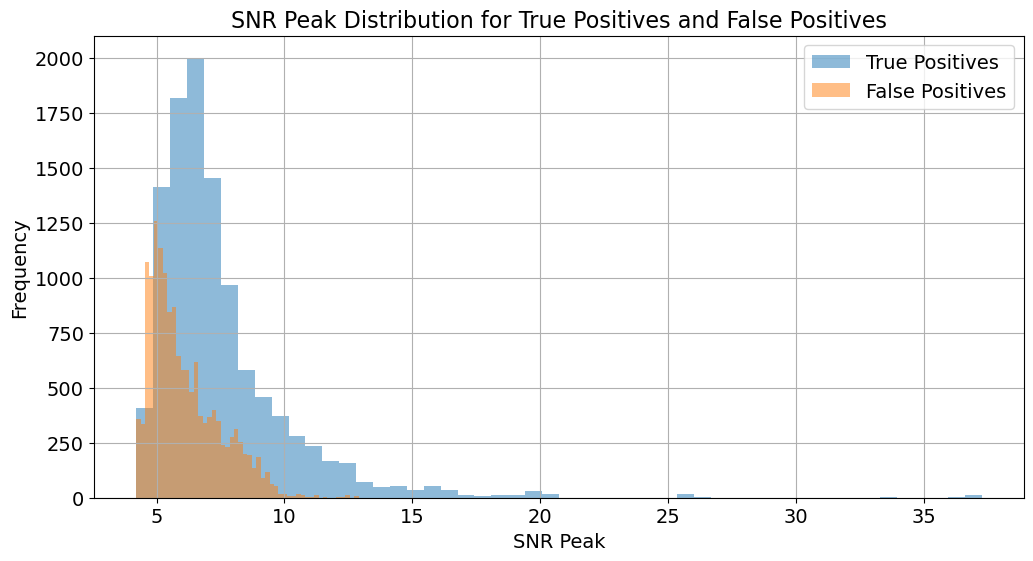

In [7]:
cf_TP.df["snr_peak"].hist(bins=50, figsize=(12, 6), alpha=0.5)
cf_FP.df["snr_peak"].hist(bins=50, figsize=(12, 6), alpha=0.5)
plt.title("SNR Peak Distribution for True Positives and False Positives")
plt.ylabel("Frequency")
plt.xlabel("SNR Peak")
plt.legend(["True Positives", "False Positives"])
plt.show()

# Distribution of Radial Position
We see a bi-modal distribution in the FPs near the core and can wall. This is where the assumption of axial symmetry breaks down.

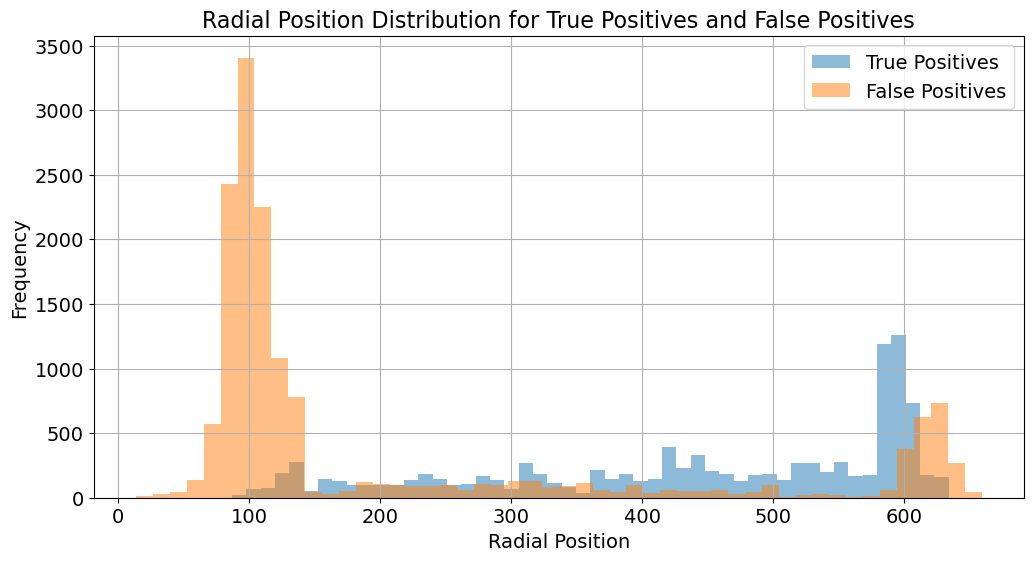

In [8]:
cf_TP.df["radial_pos"].hist(bins=50, figsize=(12, 6), alpha=0.5)
cf_FP.df["radial_pos"].hist(bins=50, figsize=(12, 6), alpha=0.5)
plt.title("Radial Position Distribution for True Positives and False Positives")
plt.ylabel("Frequency")
plt.xlabel("Radial Position")
plt.legend(["True Positives", "False Positives"])
plt.show()

In [19]:
mid_x, mid_y = 1425/2, 1425/2
samples = 10
random_rows = candidate_frame.df.sample(n=samples, random_state=42)
radial_positions = random_rows["radial_pos"].reset_index(drop=True)
peak_z = random_rows["peak_z"].reset_index(drop=True)
peak_x = random_rows["peak_x"].reset_index(drop=True)
peak_y = random_rows["peak_y"].reset_index(drop=True)
centroid_x = random_rows["centroid_x"].reset_index(drop=True)
centroid_y = random_rows["centroid_y"].reset_index(drop=True)
centroid_z = random_rows["centroid_z"].reset_index(drop=True)
print(type(random_rows))


<class 'pandas.core.frame.DataFrame'>


In [20]:

for s in range(samples):
    radial_pos = radial_positions[s]
    peak_z_val, peak_x_val, peak_y_val = peak_z[s], peak_x[s], peak_y[s]
    cen_z, cen_x, cen_y = centroid_z[s], centroid_x[s], centroid_y[s]

    p_pos = np.linalg.norm([peak_x_val - mid_x, peak_y_val - mid_y])
    c_pos = np.linalg.norm([cen_x - mid_x, cen_y - mid_y])
    print(f"Radial Position: {radial_pos}, Peak Position: {p_pos}, Centroid Position: {c_pos}")

Radial Position: 293.4114, Peak Position: 293.8001021102614, Centroid Position: 293.41124924072017
Radial Position: 424.8904, Peak Position: 425.3921720013193, Centroid Position: 424.8904251321745
Radial Position: 162.2794, Peak Position: 161.95215342810357, Centroid Position: 162.27976468124425
Radial Position: 227.9669, Peak Position: 227.821201822833, Centroid Position: 227.9666605471072
Radial Position: 525.5946, Peak Position: 525.0738043361142, Centroid Position: 525.5941750447773
Radial Position: 430.847, Peak Position: 431.36817221487263, Centroid Position: 430.8474897733535
Radial Position: 218.8892, Peak Position: 218.88924139847532, Centroid Position: 218.88924139847532
Radial Position: 229.3298, Peak Position: 229.74007051448382, Centroid Position: 229.33018574317688
Radial Position: 472.6221, Peak Position: 472.92969879253724, Centroid Position: 472.6226035051646
Radial Position: 423.7011, Peak Position: 423.4412592084054, Centroid Position: 423.70081946581126


# Logistic Regression on All Data - even with repeats

In [65]:
lr_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", LogisticRegression(max_iter=2000)),
    ]
)


X = df_classified[FEATS].replace([np.inf, -np.inf], np.nan).values
y = df_classified.particle.isin([1, 2, 3]).values
lr_pipeline.fit(X, y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('regressor', LogisticRegression(max_iter=2000))])

In [66]:
lr_model = lr_pipeline.named_steps["regressor"]
betas = lr_model.coef_
bias = lr_model.intercept_[0]
pairs = [(feat, beta) for feat, beta in zip(FEATS, betas[0])]
pairs += [("bias", bias)]
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
for feat, beta in pairs:
    print(f"{feat}: {beta:.3f} {np.exp(beta):.3f}")


r_peak: 2.497 12.150
sphericity: 1.426 4.161
fill_pca: 1.413 4.108
radial_pos: 1.286 3.620
n_seed: 1.052 2.865
snr_cluster: 0.674 1.962
gs_shell_median: 0.631 1.879
decay_drop: 0.555 1.741
edge_contrast: 0.473 1.605
gs_median: 0.414 1.513
z_extent: 0.302 1.353
r_peak_ratio: 0.199 1.220
normal_z: 0.117 1.124
axis_z: 0.040 1.041
n_seed_total: -0.005 0.995
n_voxels: -0.051 0.950
y_extent: -0.070 0.932
diag: -0.092 0.912
x_extent: -0.252 0.778
seed_grown_ratio: -0.370 0.691
linearity: -0.387 0.679
bias: -0.480 0.619
gs_contrast: -0.491 0.612
n_seed_regions: -0.504 0.604
gs_peak: -0.520 0.594
planarity: -0.754 0.470
gs_p90: -1.042 0.353
peak_offset: -1.154 0.315
snr_peak: -1.217 0.296
fill: -1.258 0.284


Train AUC: 0.9836105369985131



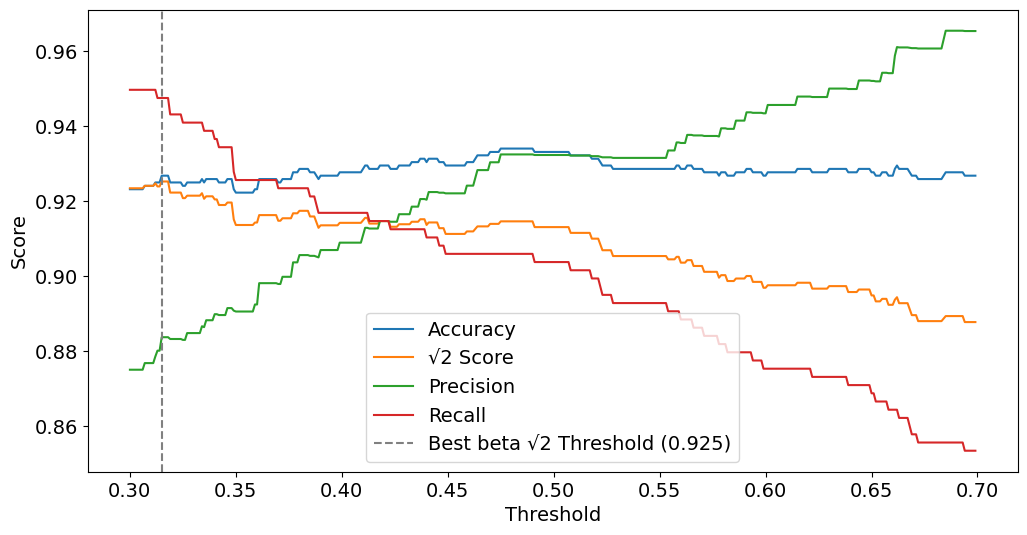

In [74]:
p_train = lr_pipeline.predict_proba(X)[:, 1]
yhat_train = (p_train >= 0.5).astype(int)
print("Train AUC:", roc_auc_score(y, p_train))
print()

acc = []
fbeta = []
prec = []
rec = []
_range = np.arange(0.3, 0.7, 0.001)
for thresh in _range:
    yhat_train = (p_train >= thresh).astype(int)
    acc.append(accuracy_score(y, yhat_train))
    fbeta.append(fbeta_score(y, yhat_train, beta=np.sqrt(2)))
    prec.append(precision_score(y, yhat_train))
    rec.append(recall_score(y, yhat_train))

plt.figure(figsize=(12, 6))
plt.plot(_range, acc, label="Accuracy")
plt.plot(_range, fbeta, label="√2 Score")
plt.plot(_range, prec, label="Precision")
plt.plot(_range, rec, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
best_fbeta = np.max(fbeta)
plt.axvline(
    x=_range[np.argmax(fbeta)],
    color="gray",
    linestyle="--",
    label=f"Best beta √2 Threshold ({best_fbeta:.3f})",
)
plt.legend(loc="best")
plt.show()


# Break out into experiments

In [3]:
experiments = sorted(df_data["experiment_number"].unique())
experiments = [int(e) for e in experiments]
print(f"Found {len(experiments)} experiments: {experiments}")

experiment_data = []
for exp in experiments:
    ed = {}
    exp_df = df_data[df_data["experiment_number"] == exp]
    ed["experiment_number"] = exp
    ed["slab_thickness"] = exp_df["slab_thickness"].iloc[0]
    ed["high_threshold_scale"] = exp_df["high_threshold_scale"].iloc[0]
    ed["low_threshold_scale"] = exp_df["low_threshold_scale"].iloc[0]
    ed["data"] = exp_df
    experiment_data.append(ed)

Found 18 experiments: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


# Feature Analysis

In [5]:
exp_idx = 15
print(f"Selected experiment {experiment_data[exp_idx]['experiment_number']}")
print(f"Slab thickness: {experiment_data[exp_idx]['slab_thickness']}")
print(f"Low threshold scale: {experiment_data[exp_idx]['low_threshold_scale']}")

Selected experiment 15
Slab thickness: 23
Low threshold scale: 2.5


## Peak Data

### SNR Peak

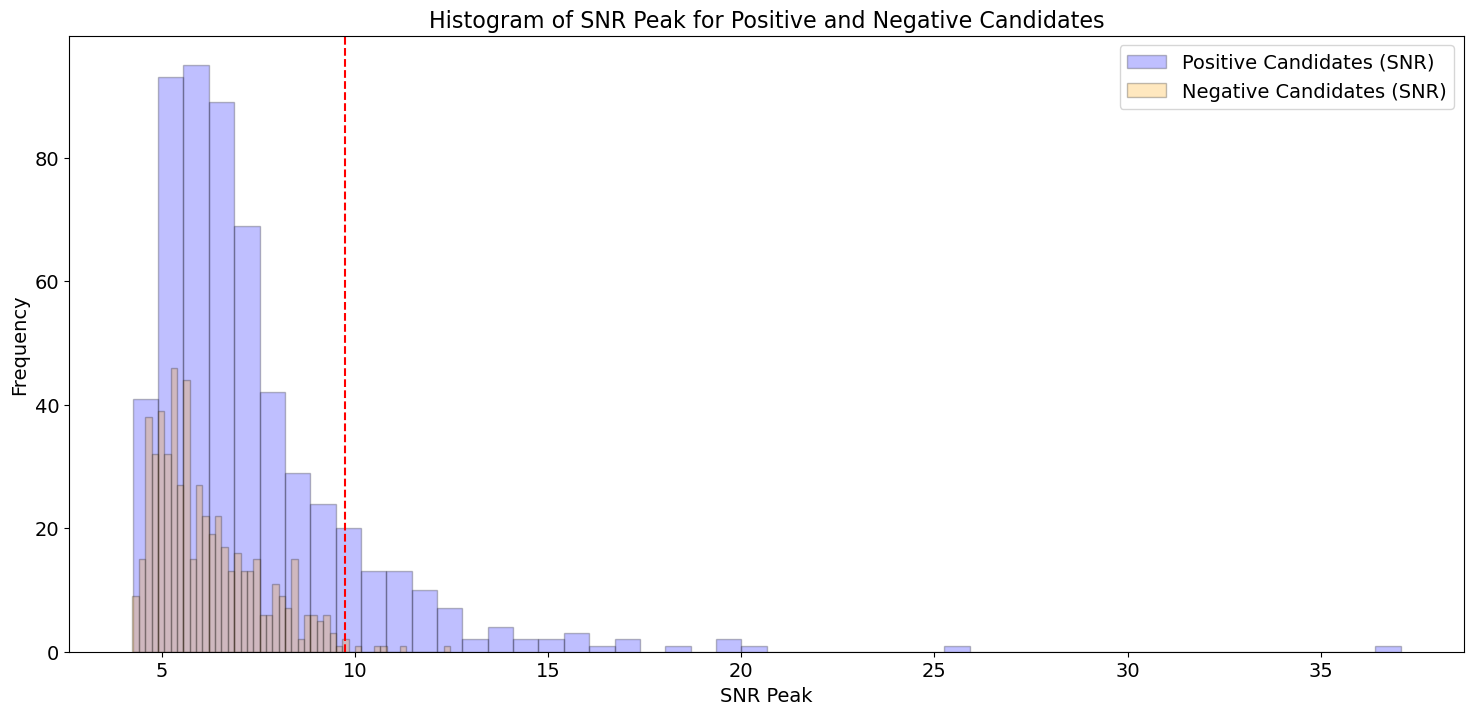

In [6]:
df = experiment_data[exp_idx]["data"]
df_pos = df[df["particle"].between(1, 4)]
df_neg = df[df["particle"] == 0]

plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["snr_peak"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (SNR)",
)
_ = plt.hist(
    df_neg["snr_peak"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (SNR)",
)
plt.legend()
plt.xlabel("SNR Peak")
plt.ylabel("Frequency")
plt.title("Histogram of SNR Peak for Positive and Negative Candidates")
plt.axvline(x=9.75, color="red", linestyle="--", label="SNR Threshold")

### Residual Peak

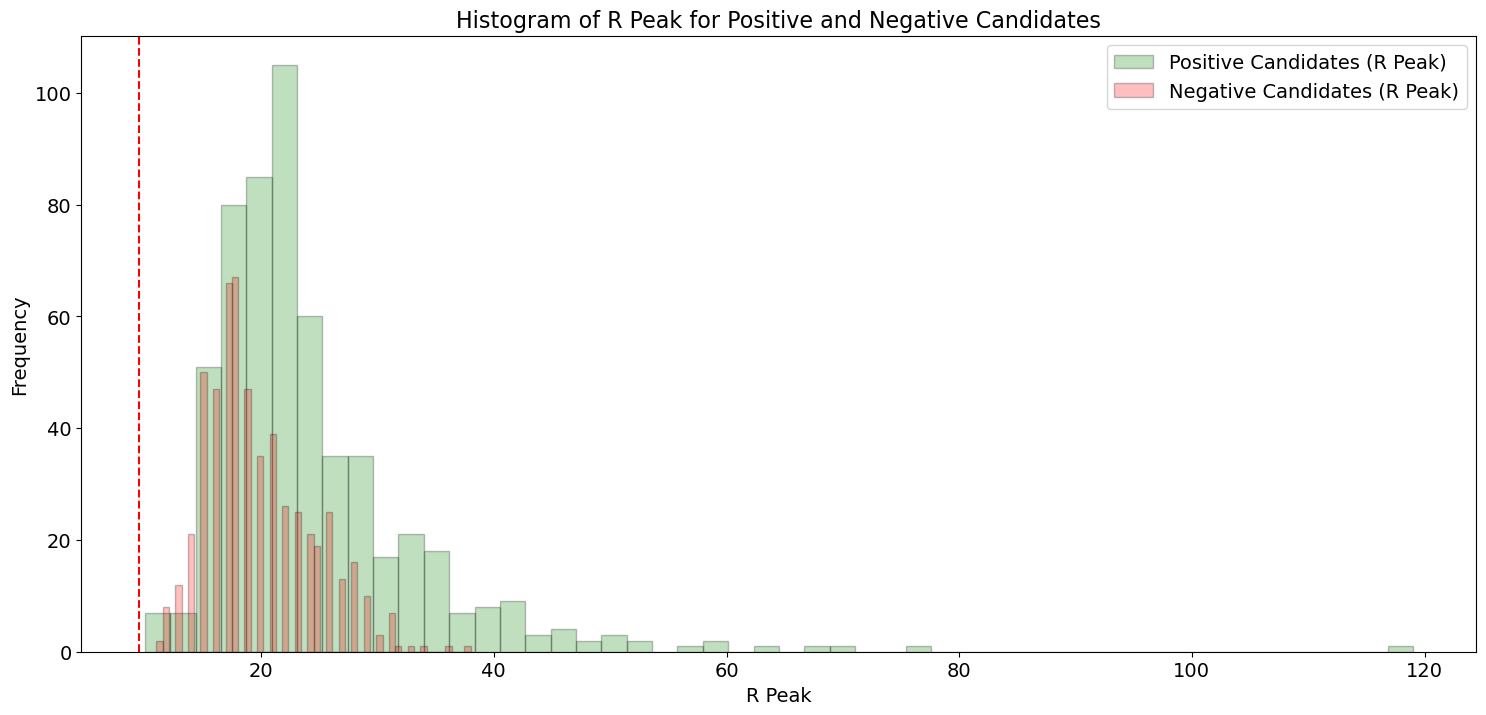

In [7]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["r_peak"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (R Peak)",
)
_ = plt.hist(
    df_neg["r_peak"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (R Peak)",
)
plt.legend()
plt.xlabel("R Peak")
plt.ylabel("Frequency")
plt.title("Histogram of R Peak for Positive and Negative Candidates")
plt.axvline(x=9.5, color="red", linestyle="--", label="R Peak Threshold")

## Cluster

### SNR Cluster

Text(0.5, 1.0, 'Histogram of SNR Cluster for Positive and Negative Candidates')

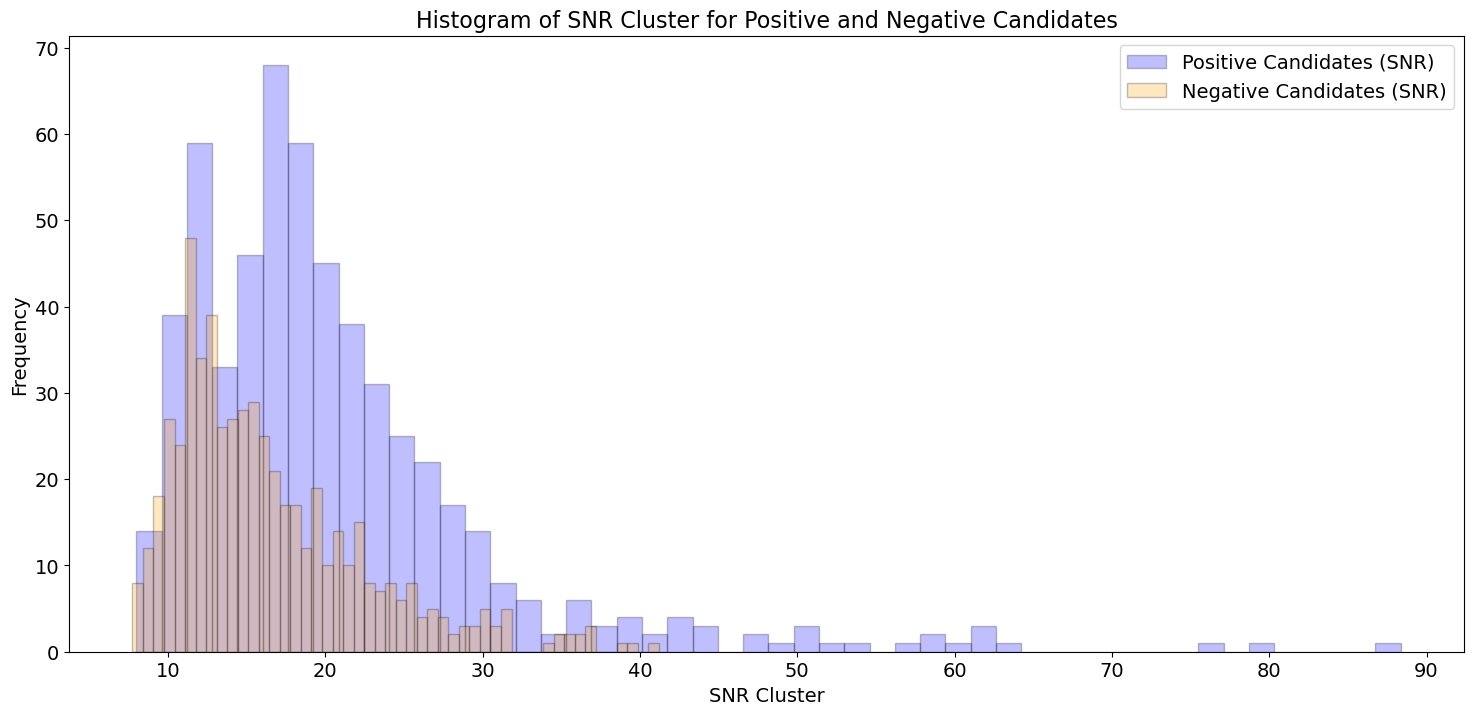

In [8]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["snr_cluster"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (SNR)",
)
_ = plt.hist(
    df_neg["snr_cluster"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (SNR)",
)
# plt.yscale('log')
plt.legend()
plt.xlabel("SNR Cluster")
plt.ylabel("Frequency")
plt.title("Histogram of SNR Cluster for Positive and Negative Candidates")
# plt.axvline(x=9.75, color='red', linestyle='--', label='SNR Threshold')

### R Peak Ratio

Text(0.5, 1.0, 'Histogram of R Peak Ratio for Positive and Negative Candidates')

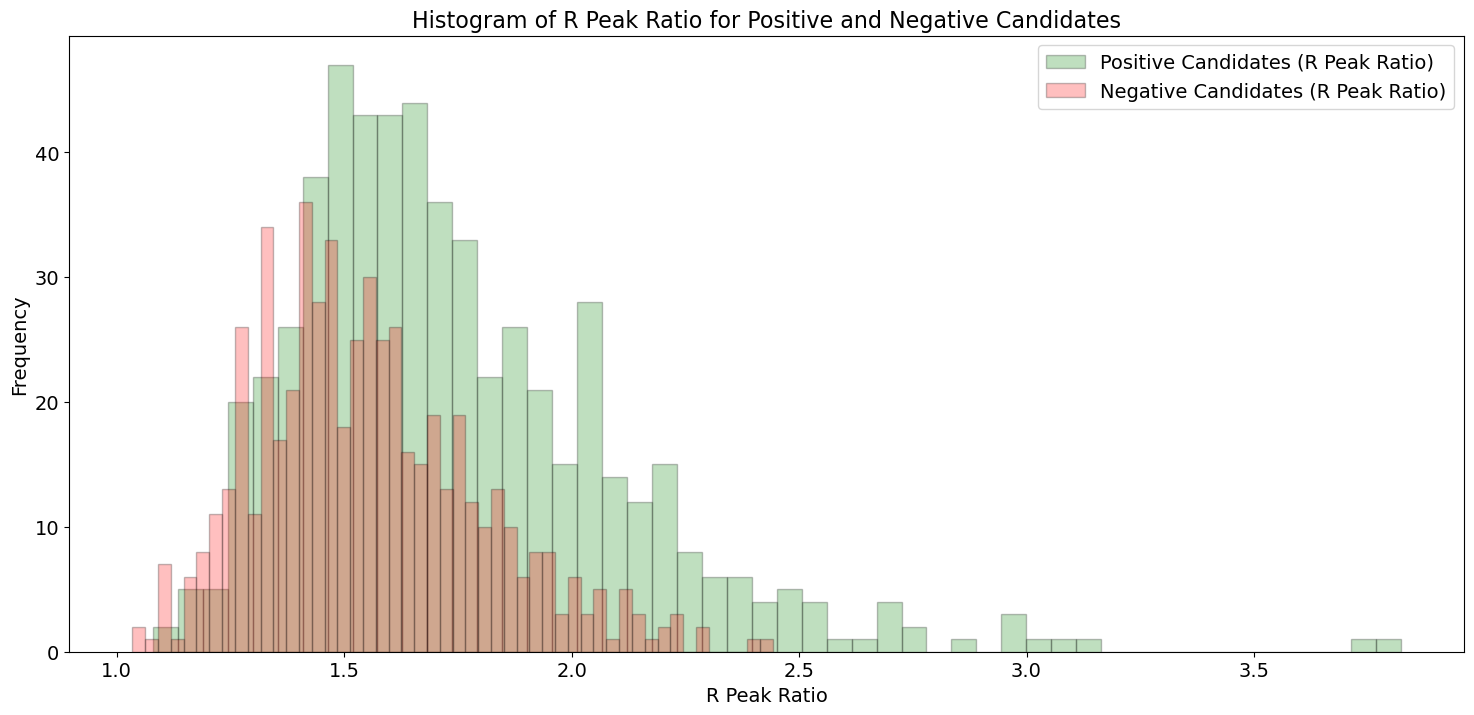

In [23]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["r_peak_ratio"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (R Peak Ratio)",
)
_ = plt.hist(
    df_neg["r_peak_ratio"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (R Peak Ratio)",
)
plt.legend()
plt.xlabel("R Peak Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of R Peak Ratio for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="R Peak Ratio Threshold")

## Voxel Volumes

### Total Voxels

Text(0.5, 1.0, 'Histogram of Number of Voxels for Positive and Negative Candidates')

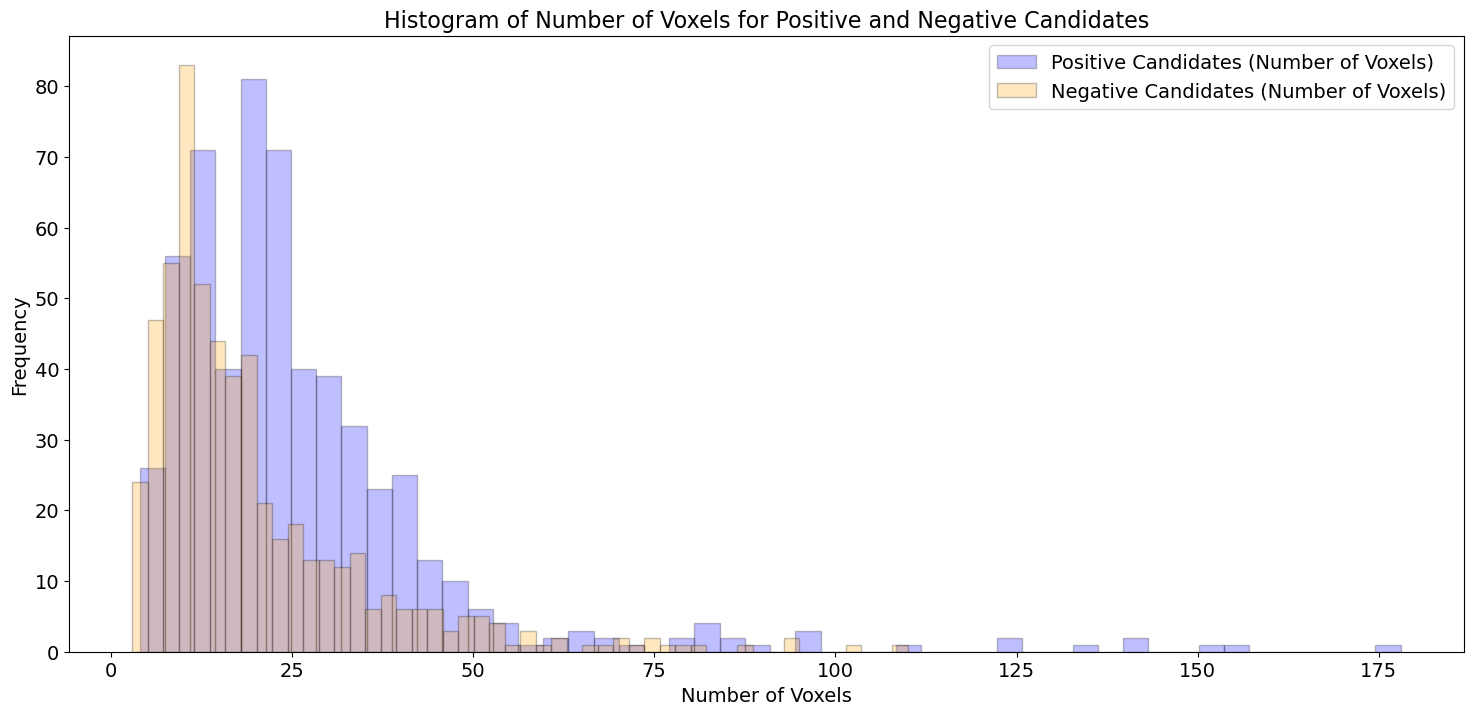

In [9]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_voxels"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (Number of Voxels)",
)
_ = plt.hist(
    df_neg["n_voxels"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (Number of Voxels)",
)
plt.legend()
plt.xlabel("Number of Voxels")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Voxels for Positive and Negative Candidates")


### Total Seed Voxels

Text(0.5, 1.0, 'Histogram of Number of Seed Total for Positive and Negative Candidates')

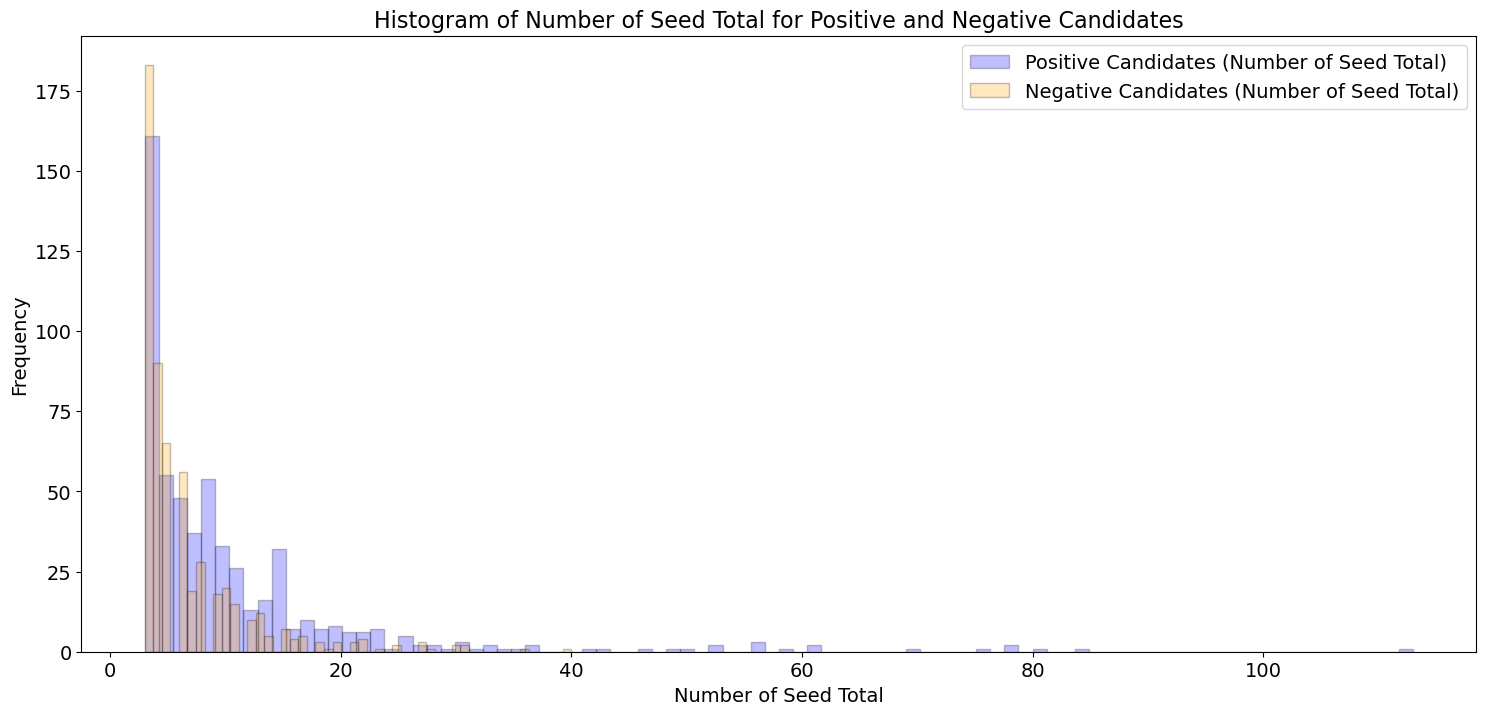

In [10]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed_total"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (Number of Seed Total)",
)
_ = plt.hist(
    df_neg["n_seed_total"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (Number of Seed Total)",
)
plt.legend()
plt.xlabel("Number of Seed Total")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Seed Total for Positive and Negative Candidates")


### Total Seed Regions

Text(0.5, 1.0, 'Histogram of Number of Seed Total for Positive and Negative Candidates')

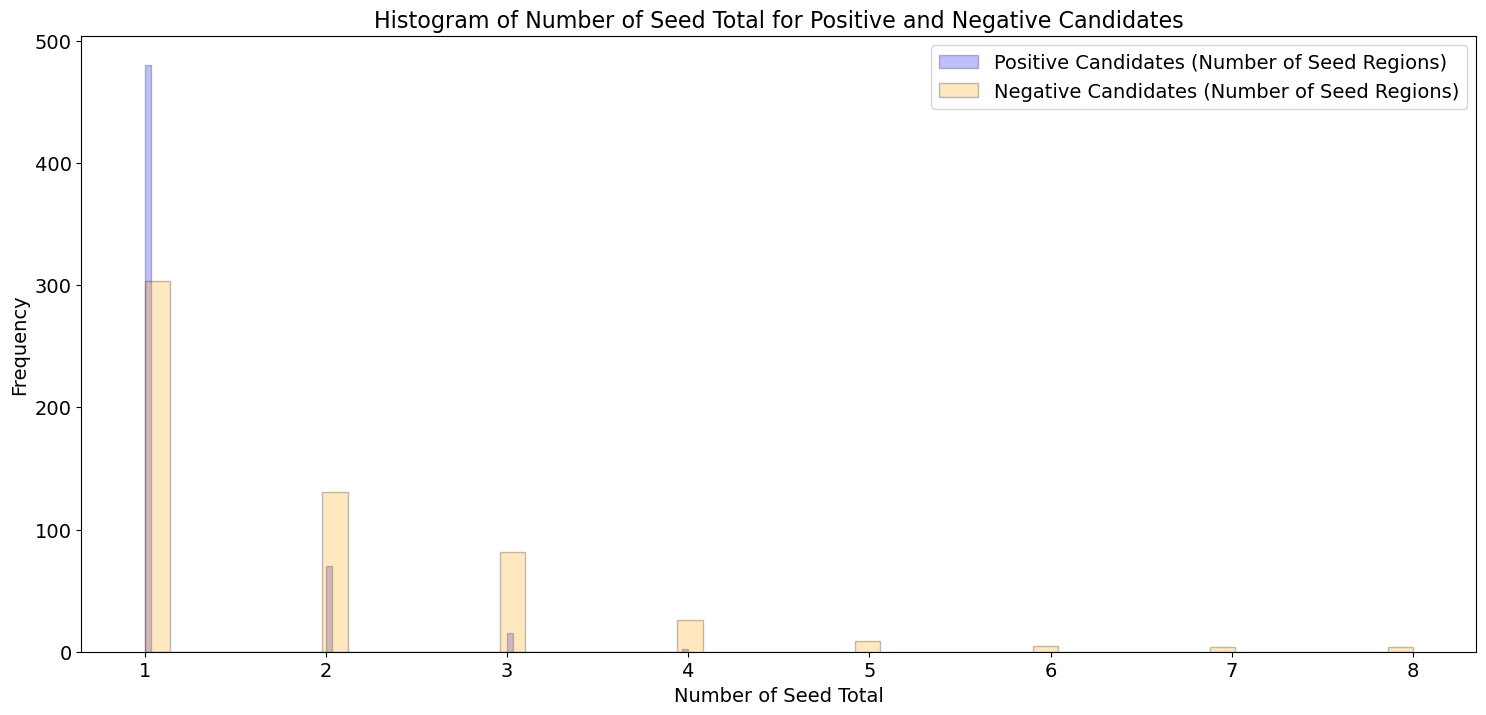

In [11]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = False
_ = plt.hist(
    df_pos["n_seed_regions"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Number of Seed Regions)",
)
_ = plt.hist(
    df_neg["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Number of Seed Regions)",
)
plt.legend()
plt.xlabel("Number of Seed Total")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Seed Total for Positive and Negative Candidates")

### Largest Seed Subregion

Text(0.5, 1.0, 'Histogram of N Seed for Positive and Negative Candidates')

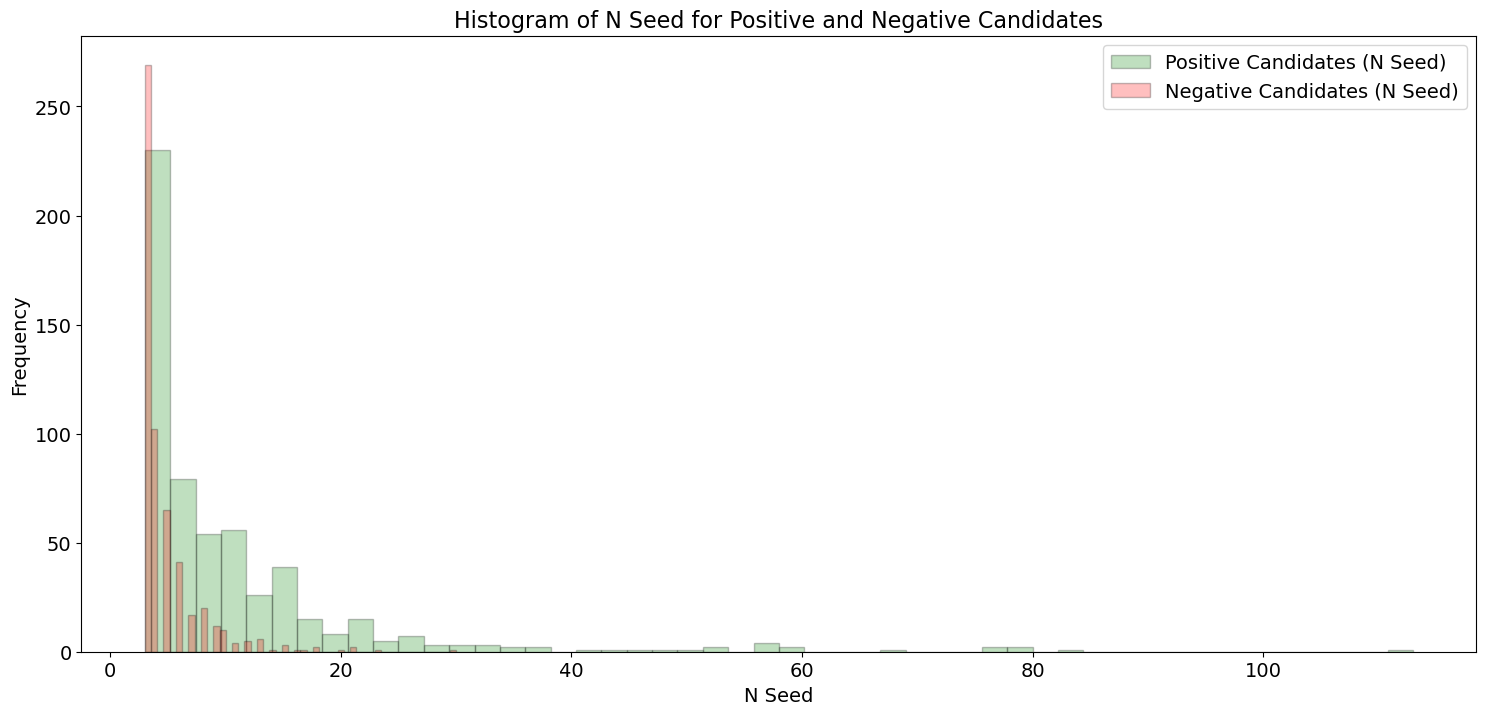

In [37]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (N Seed)",
)
_ = plt.hist(
    df_neg["n_seed"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (N Seed)",
)
plt.legend()
plt.xlabel("N Seed")
plt.ylabel("Frequency")
plt.title("Histogram of N Seed for Positive and Negative Candidates")

### Numer of Seed Subregions

Text(0.5, 1.0, 'Histogram of N Seed Regions for Positive and Negative Candidates')

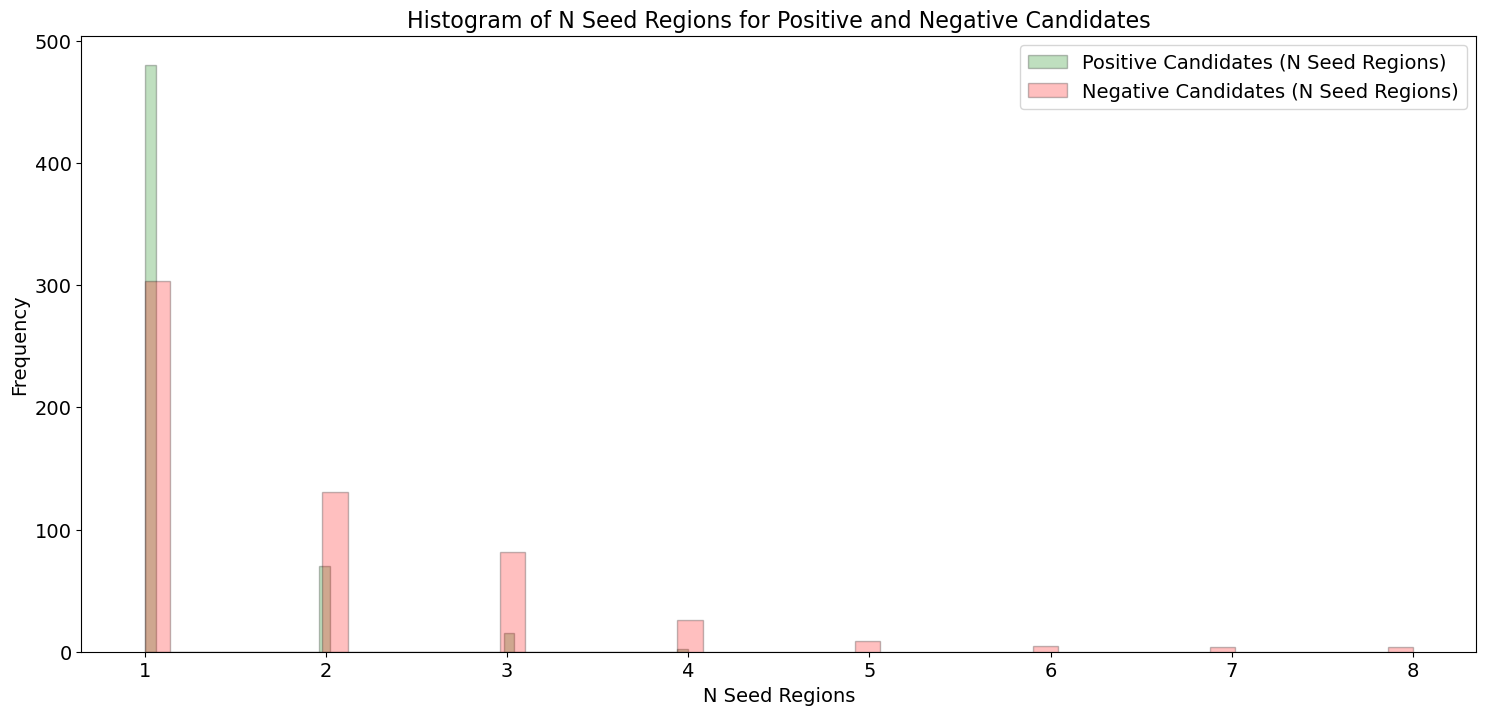

In [39]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (N Seed Regions)",
)
_ = plt.hist(
    df_neg["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (N Seed Regions)",
)
plt.legend()
plt.xlabel("N Seed Regions")
plt.ylabel("Frequency")
plt.title("Histogram of N Seed Regions for Positive and Negative Candidates")

### Seed Grown Ratio

Text(0.5, 1.0, 'Histogram of Seed Grown Ratio for Positive and Negative Candidates')

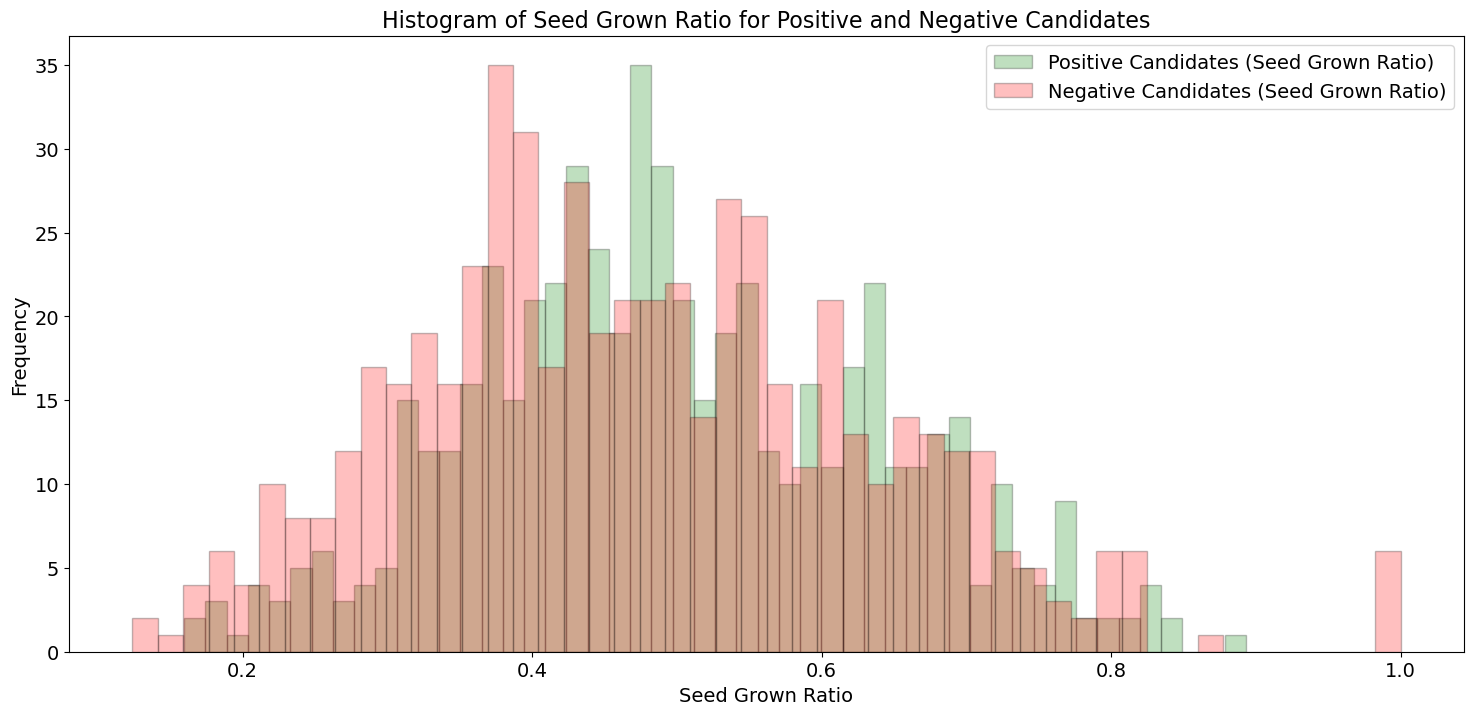

In [35]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["seed_grown_ratio"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Seed Grown Ratio)",
)
_ = plt.hist(
    df_neg["seed_grown_ratio"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Seed Grown Ratio)",
)
plt.legend()
plt.xlabel("Seed Grown Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of Seed Grown Ratio for Positive and Negative Candidates")

## Shapes

### Linearity

Text(0.5, 1.0, 'Histogram of Linearity for Positive and Negative Candidates')

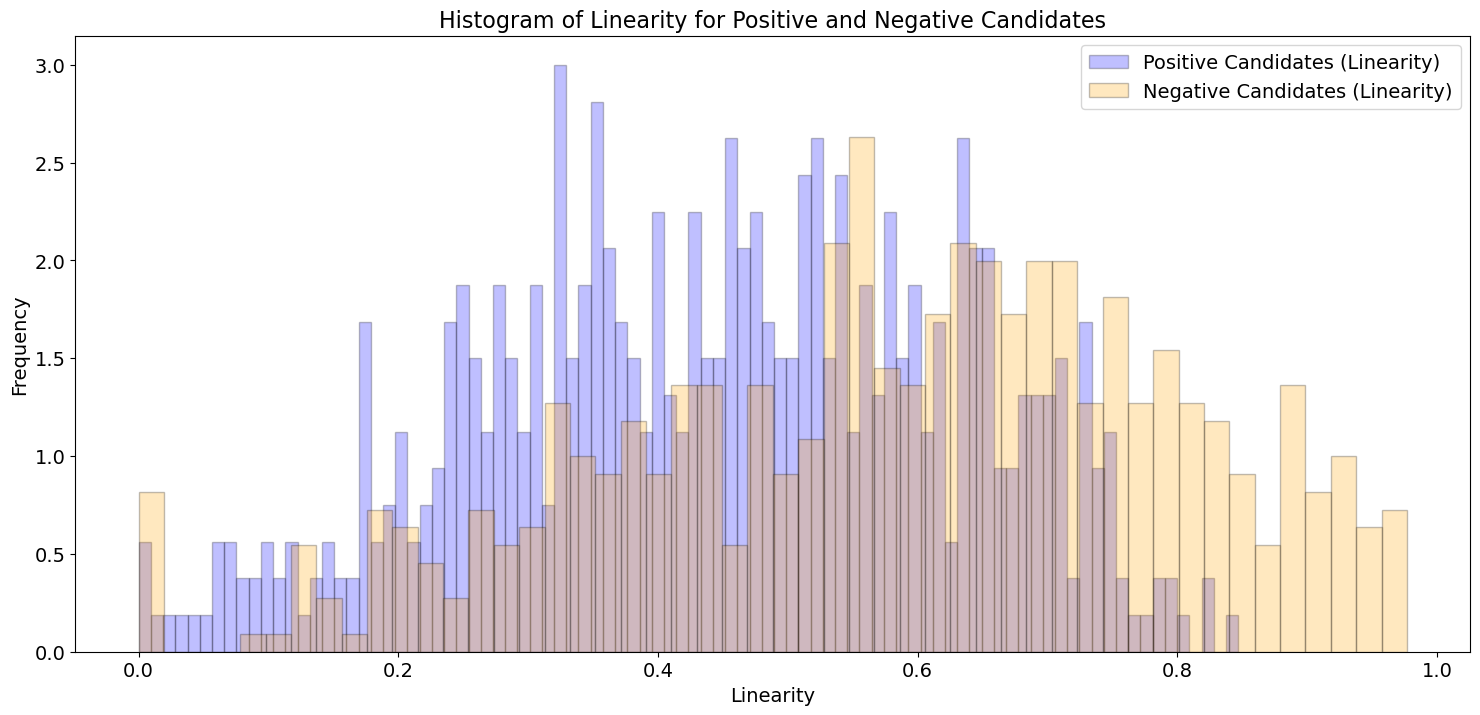

In [12]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["linearity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Linearity)",
)
_ = plt.hist(
    df_neg["linearity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Linearity)",
)
plt.legend()
plt.xlabel("Linearity")
plt.ylabel("Frequency")
plt.title("Histogram of Linearity for Positive and Negative Candidates")

### Planarity

Text(0.5, 1.0, 'Histogram of Planarity for Positive and Negative Candidates')

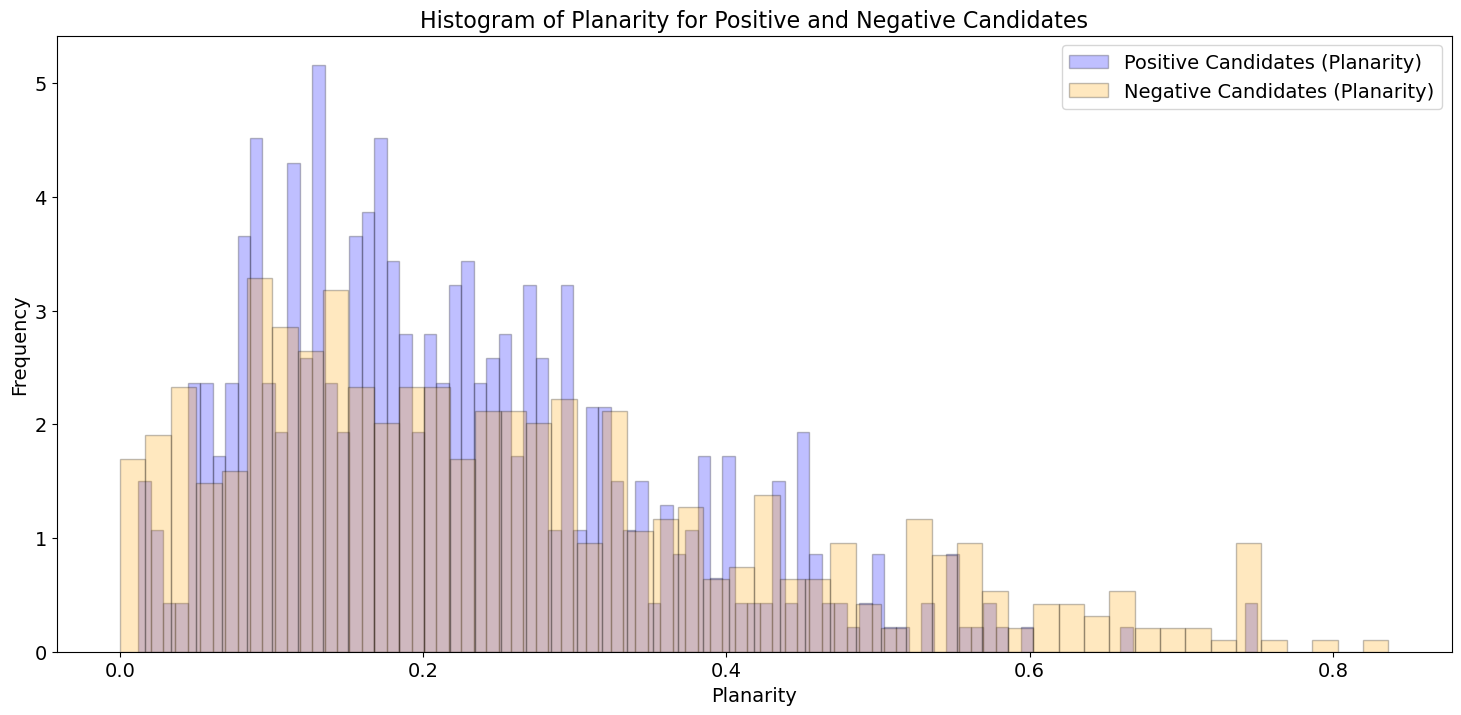

In [13]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["planarity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Planarity)",
)
_ = plt.hist(
    df_neg["planarity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Planarity)",
)
plt.legend()
plt.xlabel("Planarity")
plt.ylabel("Frequency")
plt.title("Histogram of Planarity for Positive and Negative Candidates")

### Sphericity

Text(0.5, 1.0, 'Histogram of Sphericity for Positive and Negative Candidates')

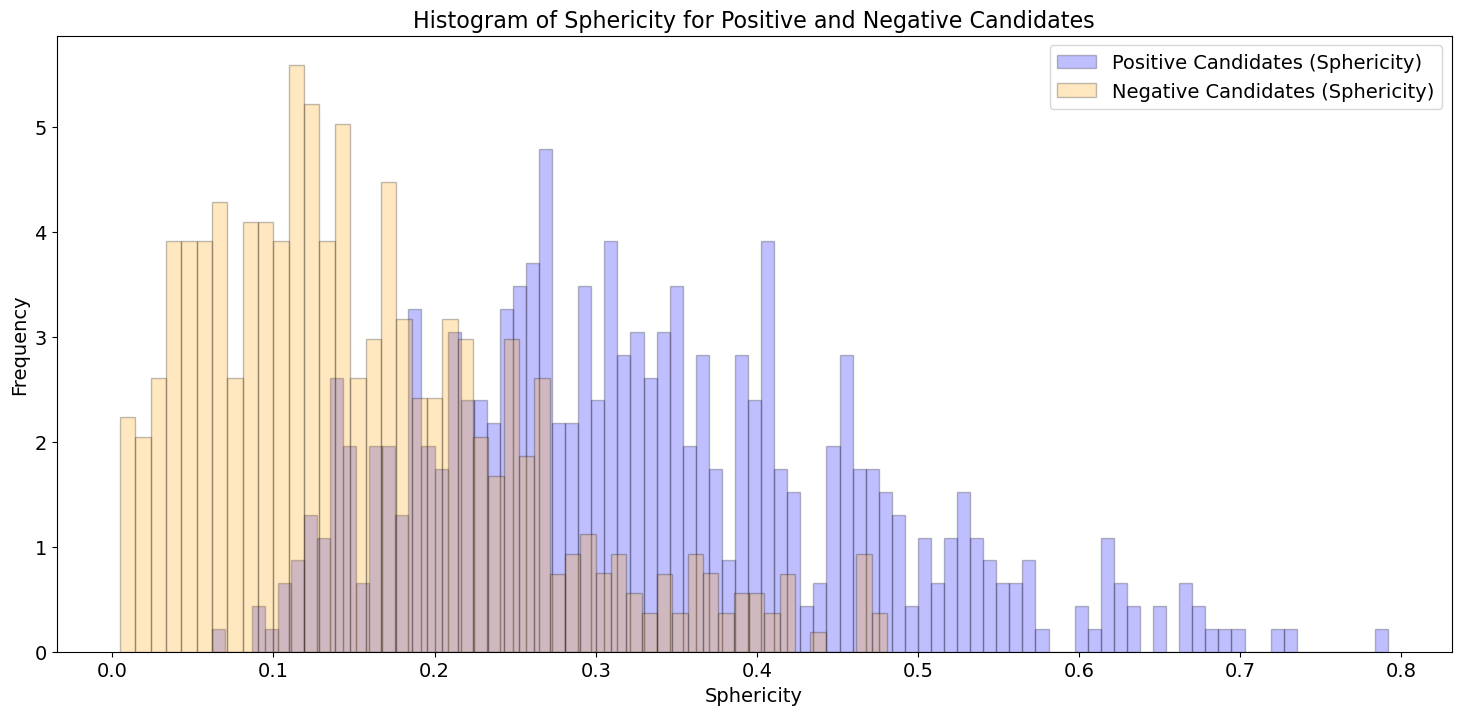

In [14]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["sphericity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Sphericity)",
)
_ = plt.hist(
    df_neg["sphericity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Sphericity)",
)
plt.legend()
plt.xlabel("Sphericity")
plt.ylabel("Frequency")
plt.title("Histogram of Sphericity for Positive and Negative Candidates")

## Fill

### Fill from Bounding Box

Text(0.5, 1.0, 'Histogram of Fill Ratio for Positive and Negative Candidates')

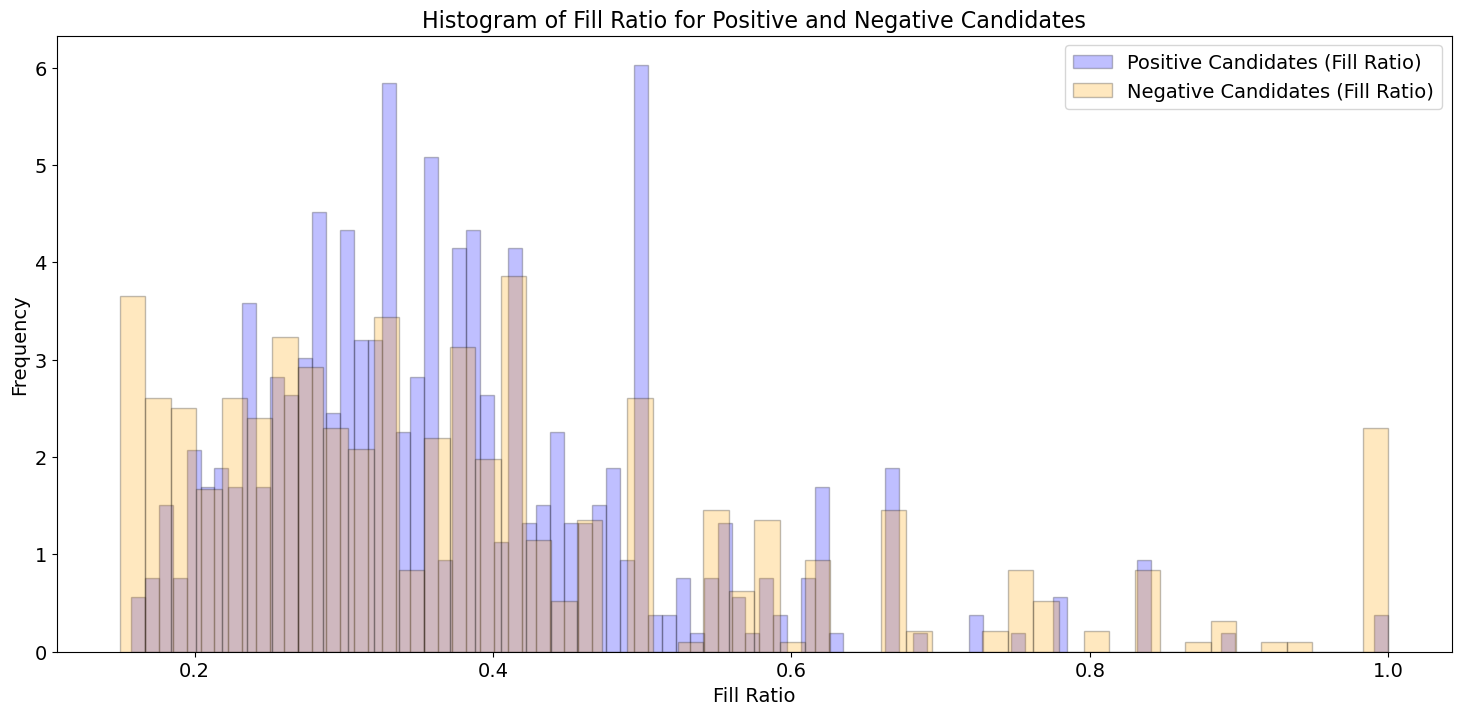

In [15]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["fill"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Fill Ratio)",
)
_ = plt.hist(
    df_neg["fill"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Fill Ratio)",
)
plt.legend()
plt.xlabel("Fill Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of Fill Ratio for Positive and Negative Candidates")

### Fill from PCA Ellipsoid

Text(0.5, 1.0, 'Histogram of Fill PCA for Positive and Negative Candidates')

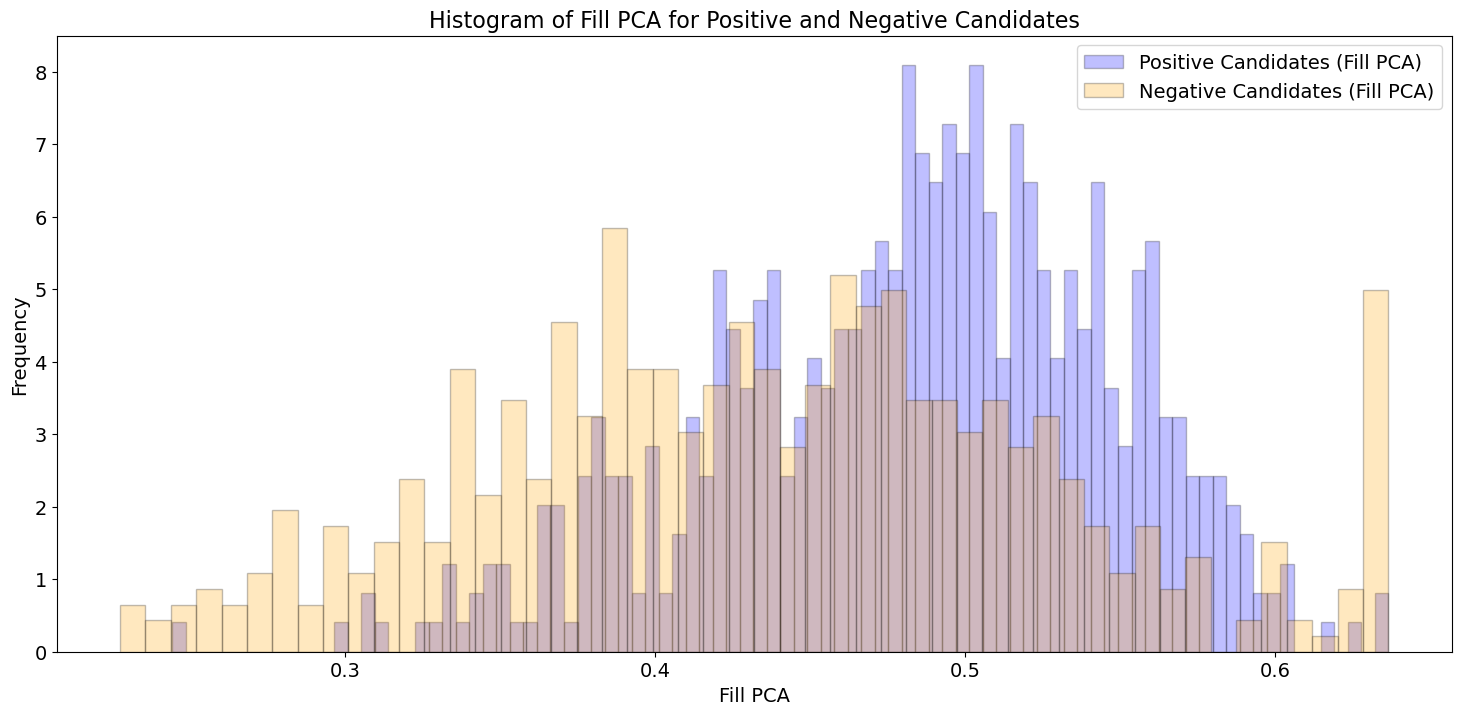

In [16]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["fill_pca"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Fill PCA)",
)
_ = plt.hist(
    df_neg["fill_pca"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Fill PCA)",
)
plt.legend()
plt.xlabel("Fill PCA")
plt.ylabel("Frequency")
plt.title("Histogram of Fill PCA for Positive and Negative Candidates")

## Contrast

### Residual SNR Edge Contrast

Text(0.5, 1.0, 'Histogram of Edge Contrast for Positive and Negative Candidates')

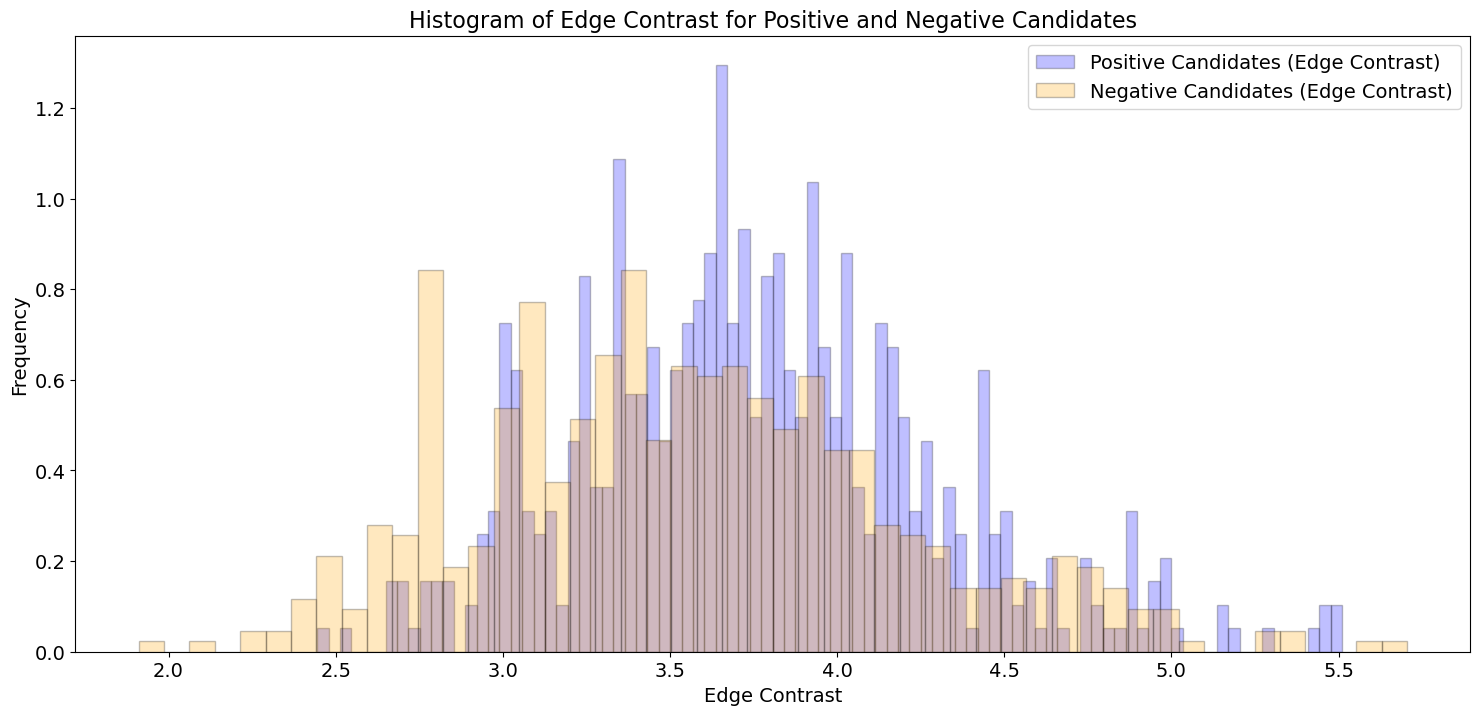

In [17]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["edge_contrast"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Edge Contrast)",
)
_ = plt.hist(
    df_neg["edge_contrast"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Edge Contrast)",
)
plt.legend()
plt.xlabel("Edge Contrast")
plt.ylabel("Frequency")
plt.title("Histogram of Edge Contrast for Positive and Negative Candidates")

### Residual SNR Decay Drop

Text(0.5, 1.0, 'Histogram of Decay Drop for Positive and Negative Candidates')

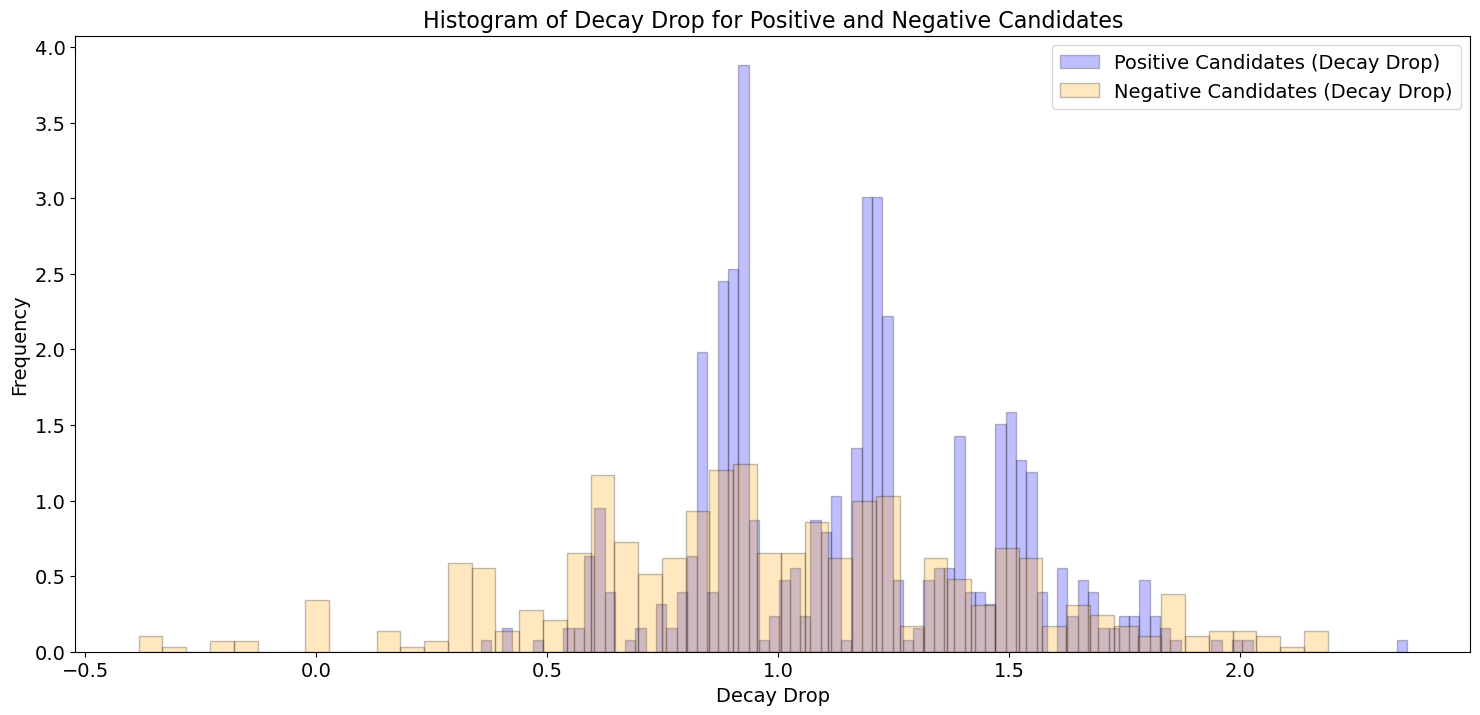

In [18]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["decay_drop"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Decay Drop)",
)
_ = plt.hist(
    df_neg["decay_drop"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Decay Drop)",
)
plt.legend()
plt.xlabel("Decay Drop")
plt.ylabel("Frequency")
plt.title("Histogram of Decay Drop for Positive and Negative Candidates")

### Grayscale Contrast

Text(0.5, 1.0, 'Histogram of GS Contrast for Positive and Negative Candidates')

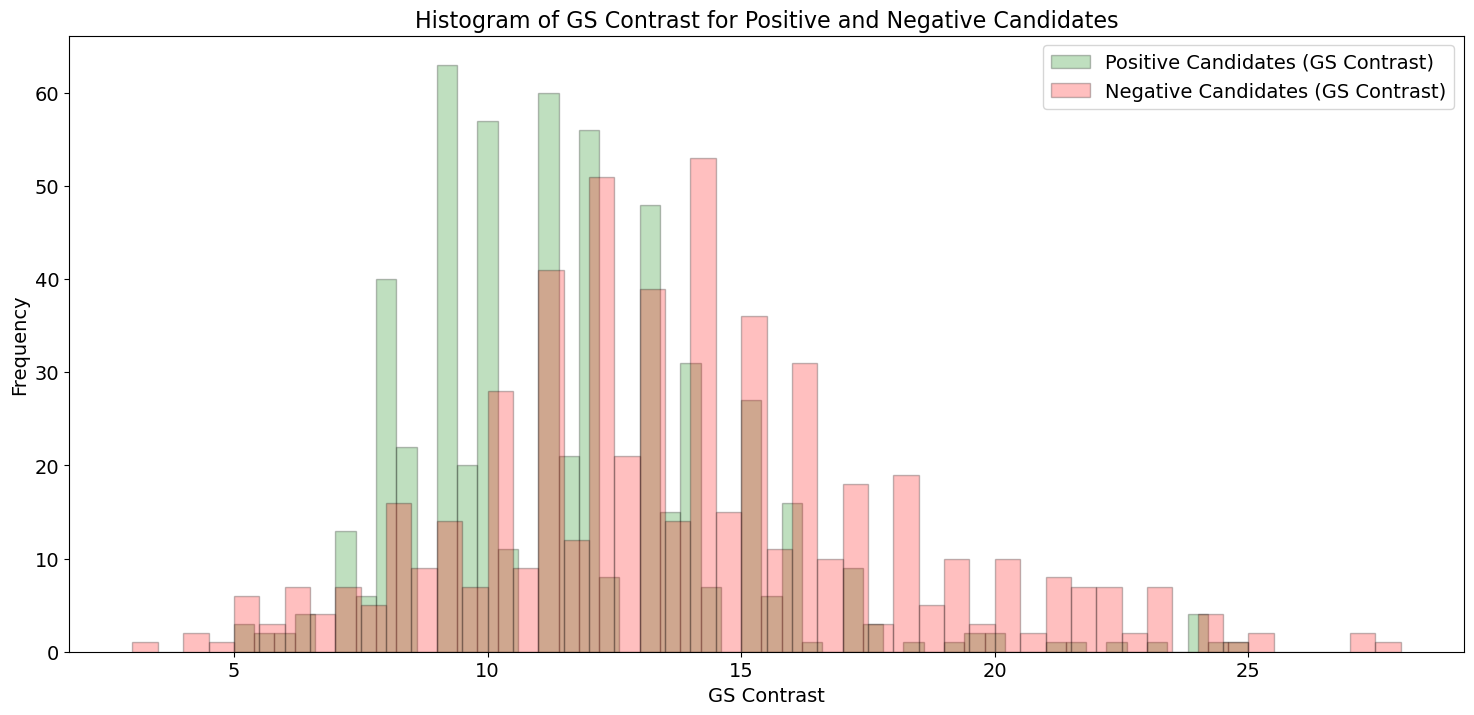

In [24]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_contrast"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Contrast)",
)
_ = plt.hist(
    df_neg["gs_contrast"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Contrast)",
)
plt.legend()
plt.xlabel("GS Contrast")
plt.ylabel("Frequency")
plt.title("Histogram of GS Contrast for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="GS Contrast Threshold")

## Grayscale Values

### Peak Grayscale

Text(0.5, 1.0, 'Histogram of GS Peak for Positive and Negative Candidates')

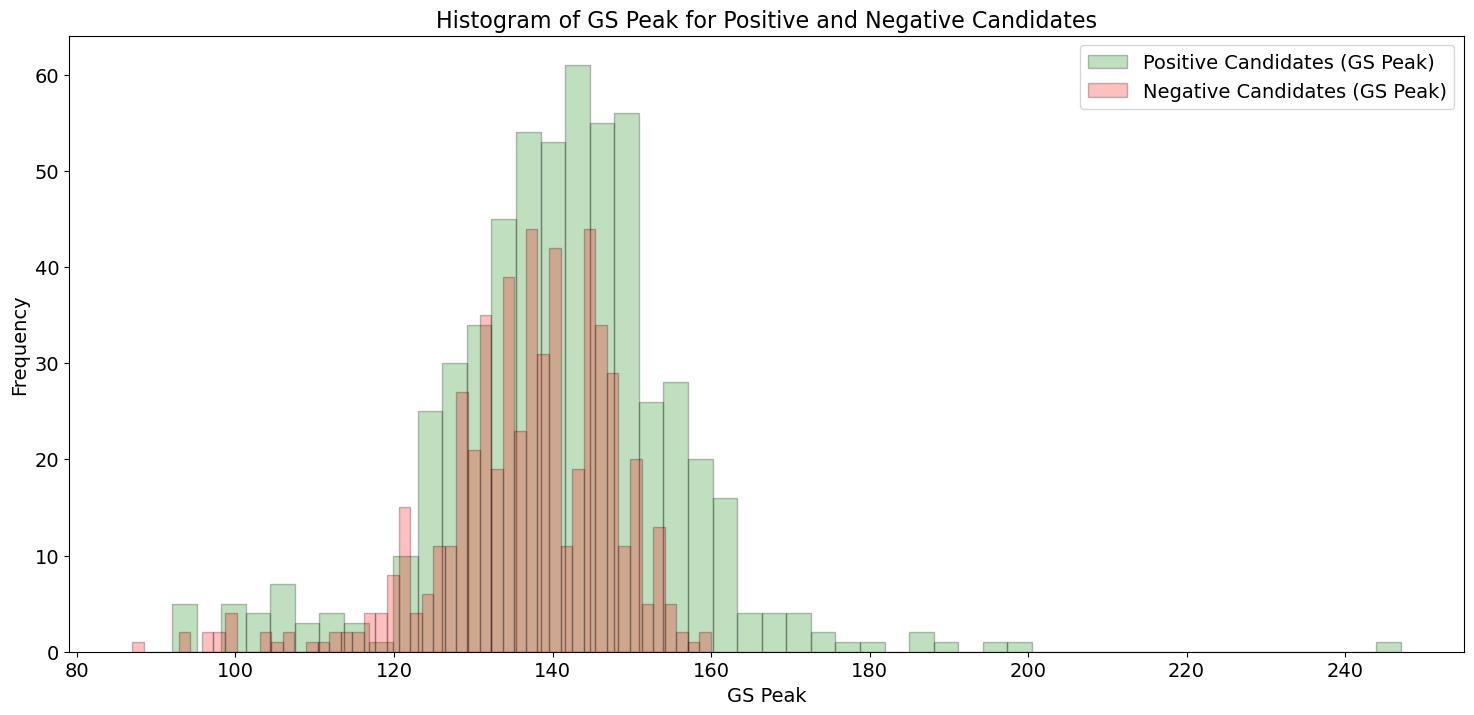

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_peak"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Peak)",
)
_ = plt.hist(
    df_neg["gs_peak"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Peak)",
)
plt.legend()
plt.xlabel("GS Peak")
plt.ylabel("Frequency")
plt.title("Histogram of GS Peak for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="GS Peak Threshold")

### Median Grayscale

Text(0.5, 1.0, 'Histogram of GS Median for Positive and Negative Candidates')

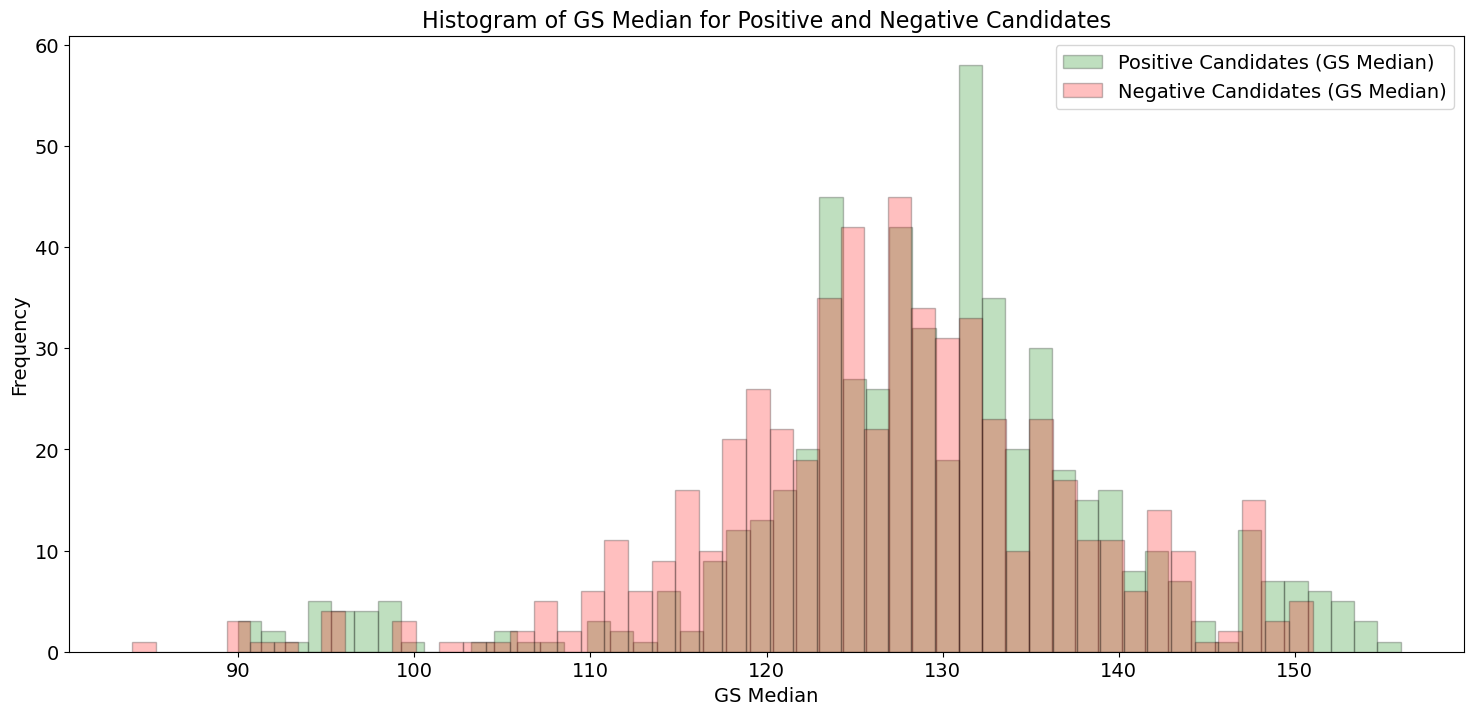

In [26]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_median"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Median)",
)
_ = plt.hist(
    df_neg["gs_median"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Median)",
)
plt.legend()
plt.xlabel("GS Median")
plt.ylabel("Frequency")
plt.title("Histogram of GS Median for Positive and Negative Candidates")


### Grayscale P90

Text(0.5, 1.0, 'Histogram of GS P90 for Positive and Negative Candidates')

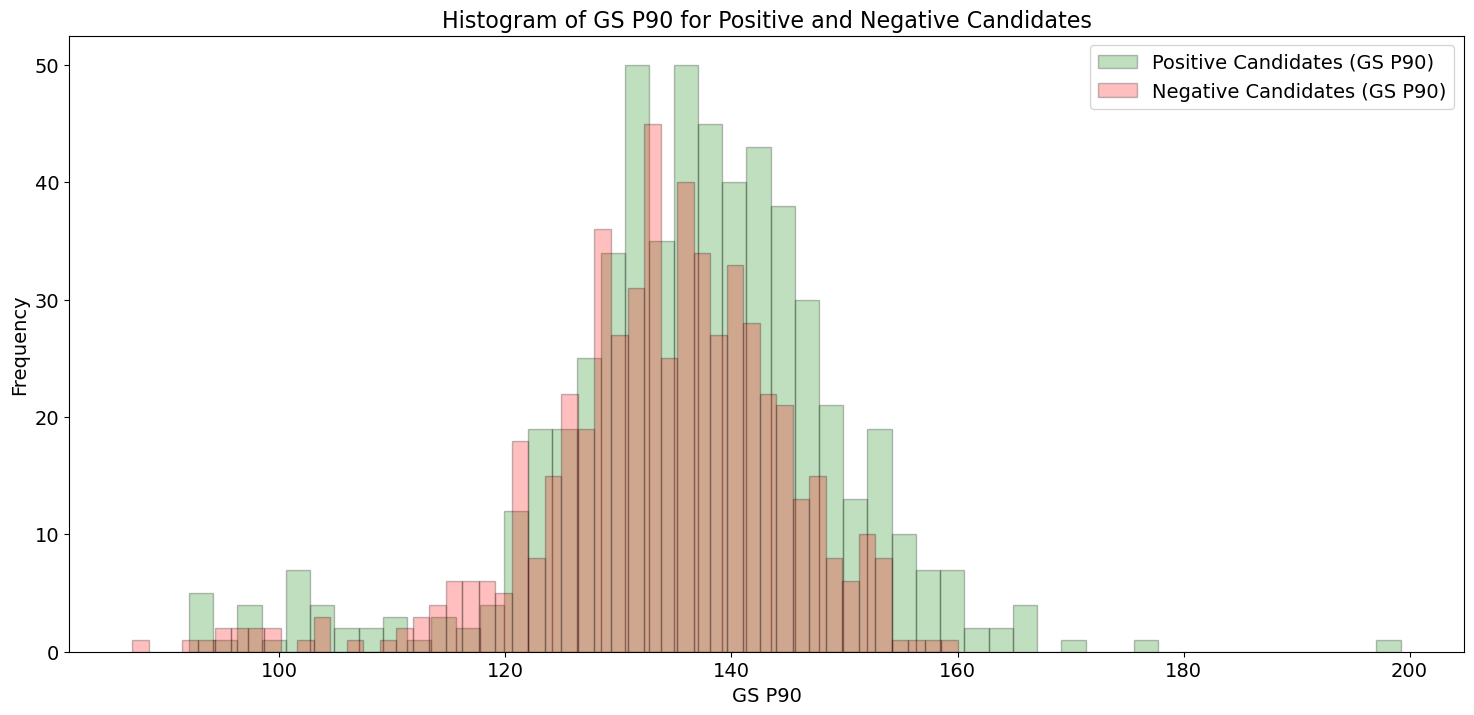

In [27]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_p90"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS P90)",
)
_ = plt.hist(
    df_neg["gs_p90"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS P90)",
)
plt.legend()
plt.xlabel("GS P90")
plt.ylabel("Frequency")
plt.title("Histogram of GS P90 for Positive and Negative Candidates")

### Shell Median

Text(0.5, 1.0, 'Histogram of GS Shell Median for Positive and Negative Candidates')

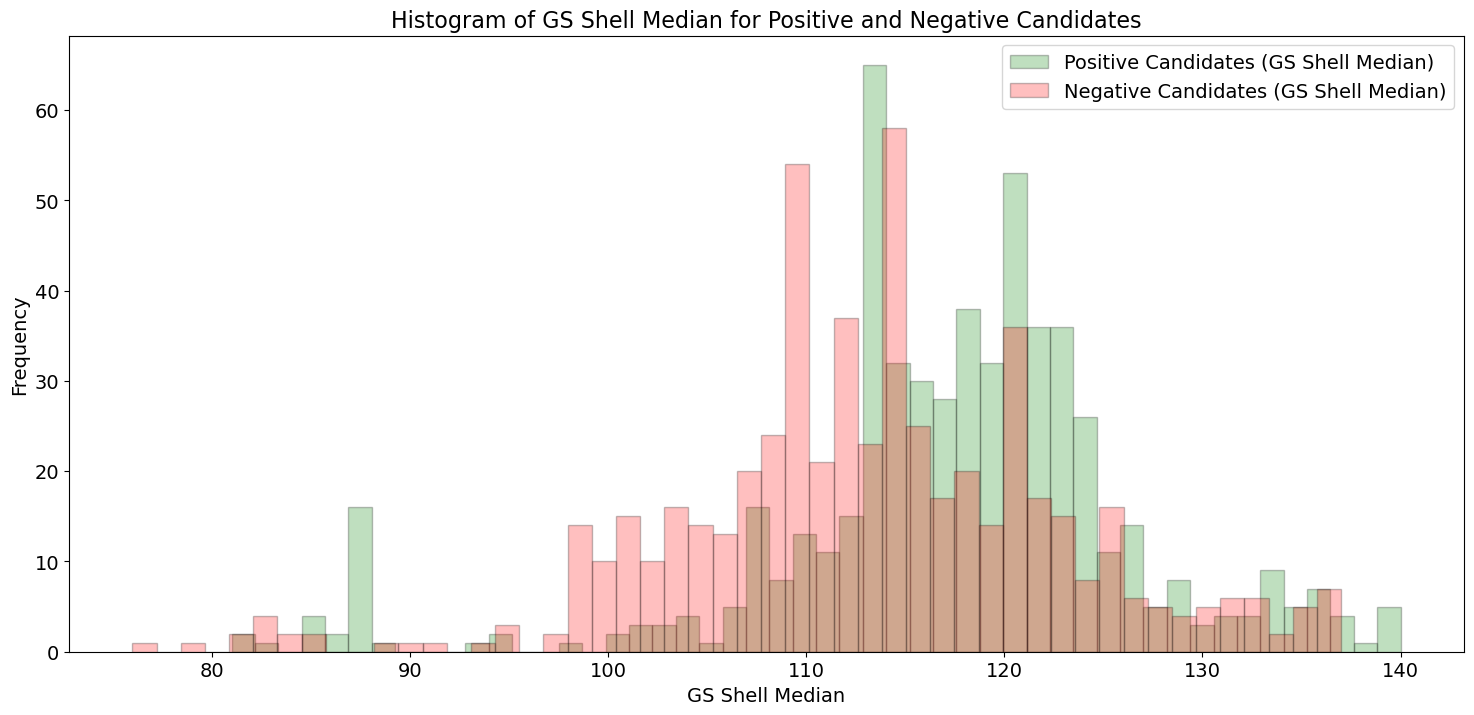

In [28]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_shell_median"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Shell Median)",
)
_ = plt.hist(
    df_neg["gs_shell_median"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Shell Median)",
)
plt.legend()
plt.xlabel("GS Shell Median")
plt.ylabel("Frequency")
plt.title("Histogram of GS Shell Median for Positive and Negative Candidates")

## Misc

### Peak Offset

Text(0.5, 1.0, 'Histogram of Peak Offset for Positive and Negative Candidates')

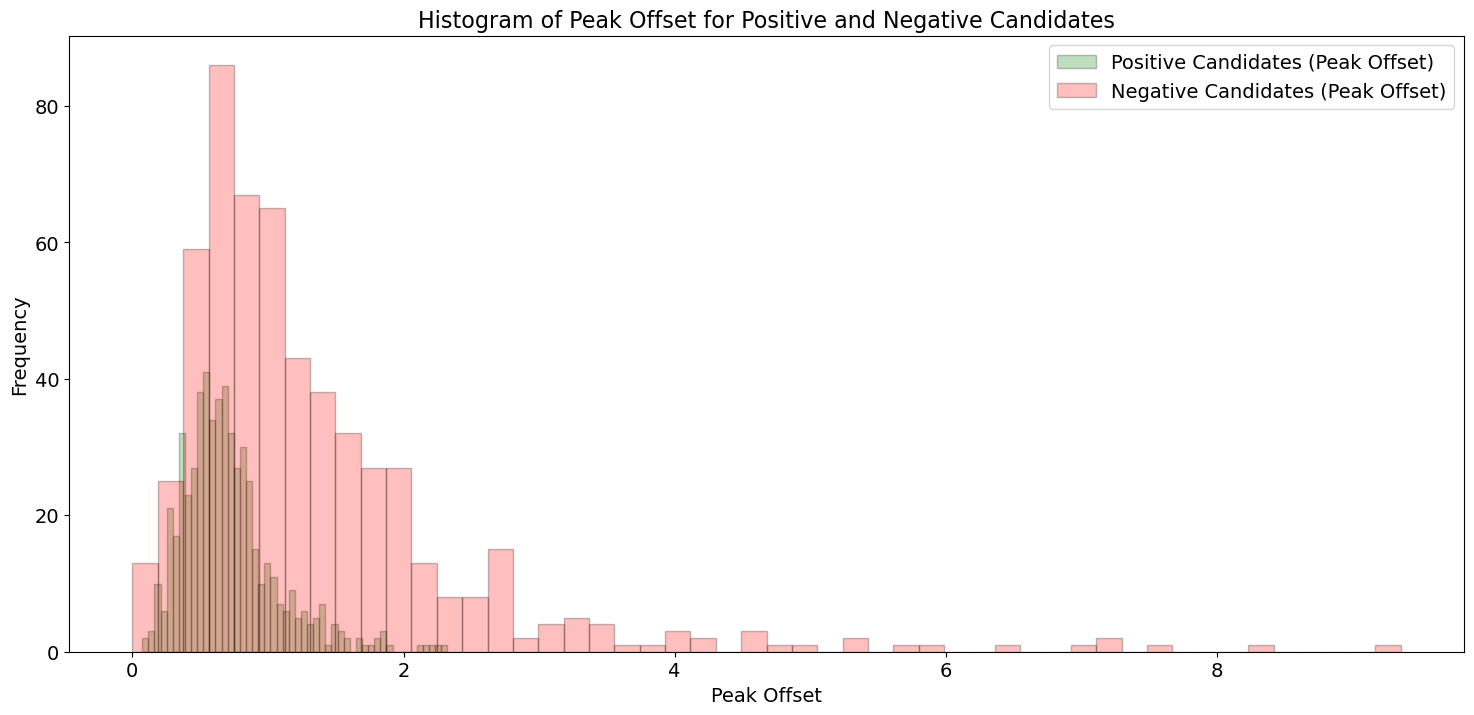

In [30]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["peak_offset"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Peak Offset)",
)
_ = plt.hist(
    df_neg["peak_offset"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Peak Offset)",
)
plt.legend()
plt.xlabel("Peak Offset")
plt.ylabel("Frequency")
plt.title("Histogram of Peak Offset for Positive and Negative Candidates")

### Axis Z

Text(0.5, 1.0, 'Histogram of Axis Z for Positive and Negative Candidates')

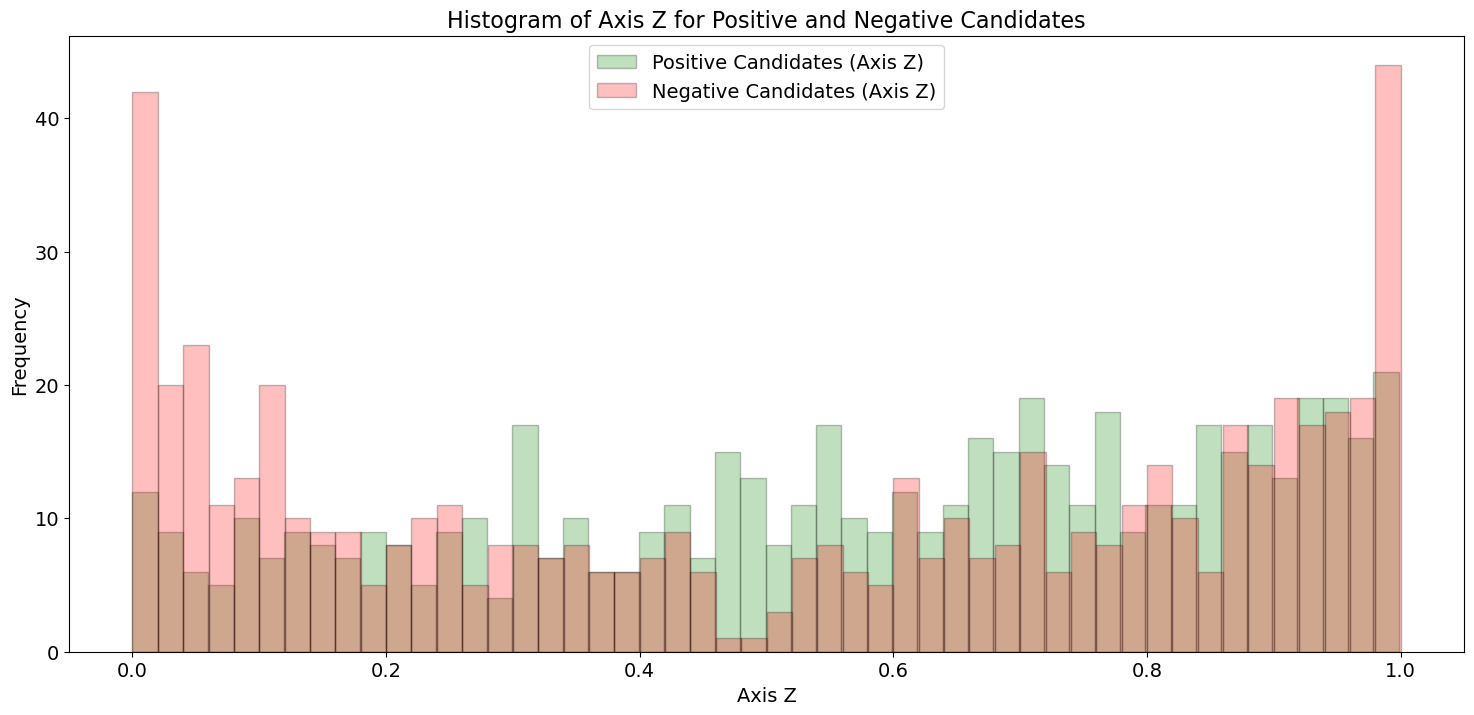

In [31]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["axis_z"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Axis Z)",
)
_ = plt.hist(
    df_neg["axis_z"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Axis Z)",
)
plt.legend()
plt.xlabel("Axis Z")
plt.ylabel("Frequency")
plt.title("Histogram of Axis Z for Positive and Negative Candidates")

Text(0.5, 1.0, 'Histogram of Normal Z for Positive and Negative Candidates')

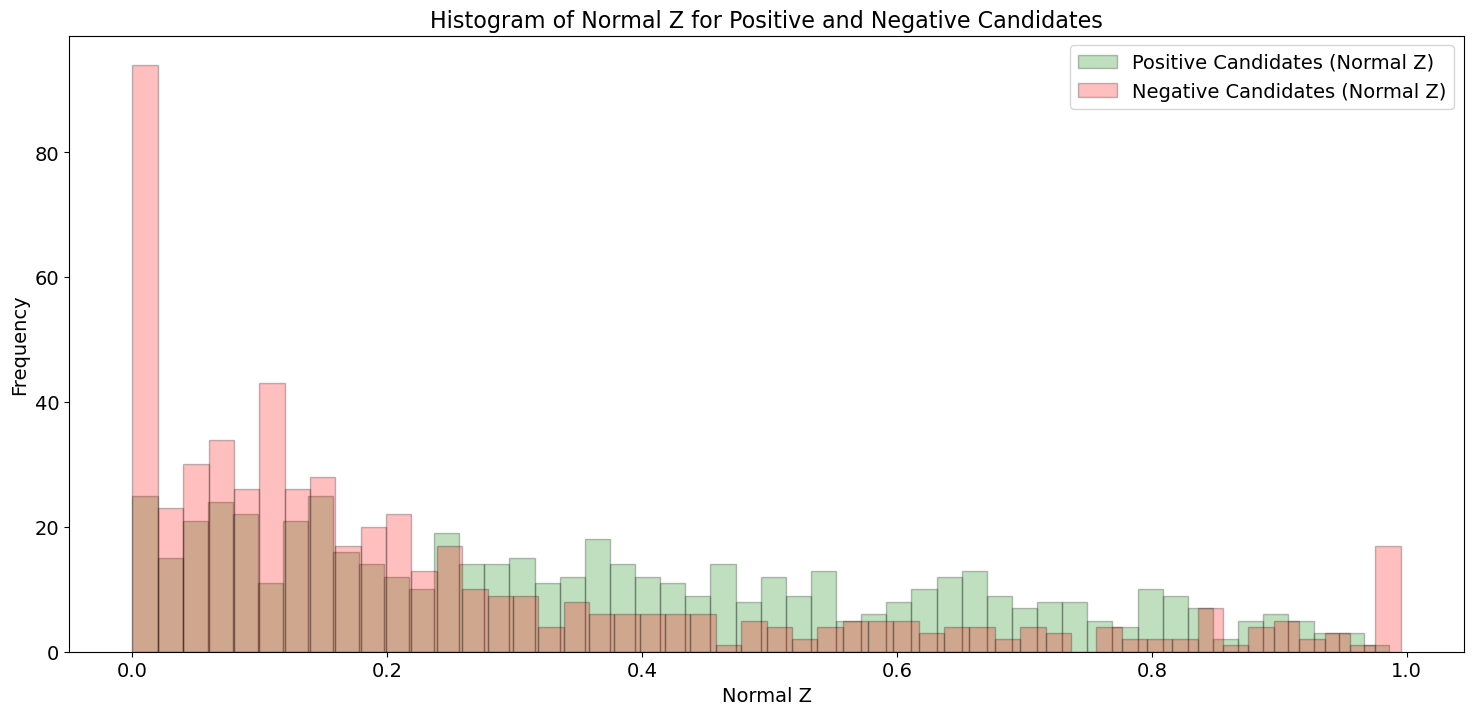

In [32]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["normal_z"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Normal Z)",
)
_ = plt.hist(
    df_neg["normal_z"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Normal Z)",
)
plt.legend()
plt.xlabel("Normal Z")
plt.ylabel("Frequency")
plt.title("Histogram of Normal Z for Positive and Negative Candidates")

### Diagonal

Text(0.5, 1.0, 'Histogram of Diagonal for Positive and Negative Candidates')

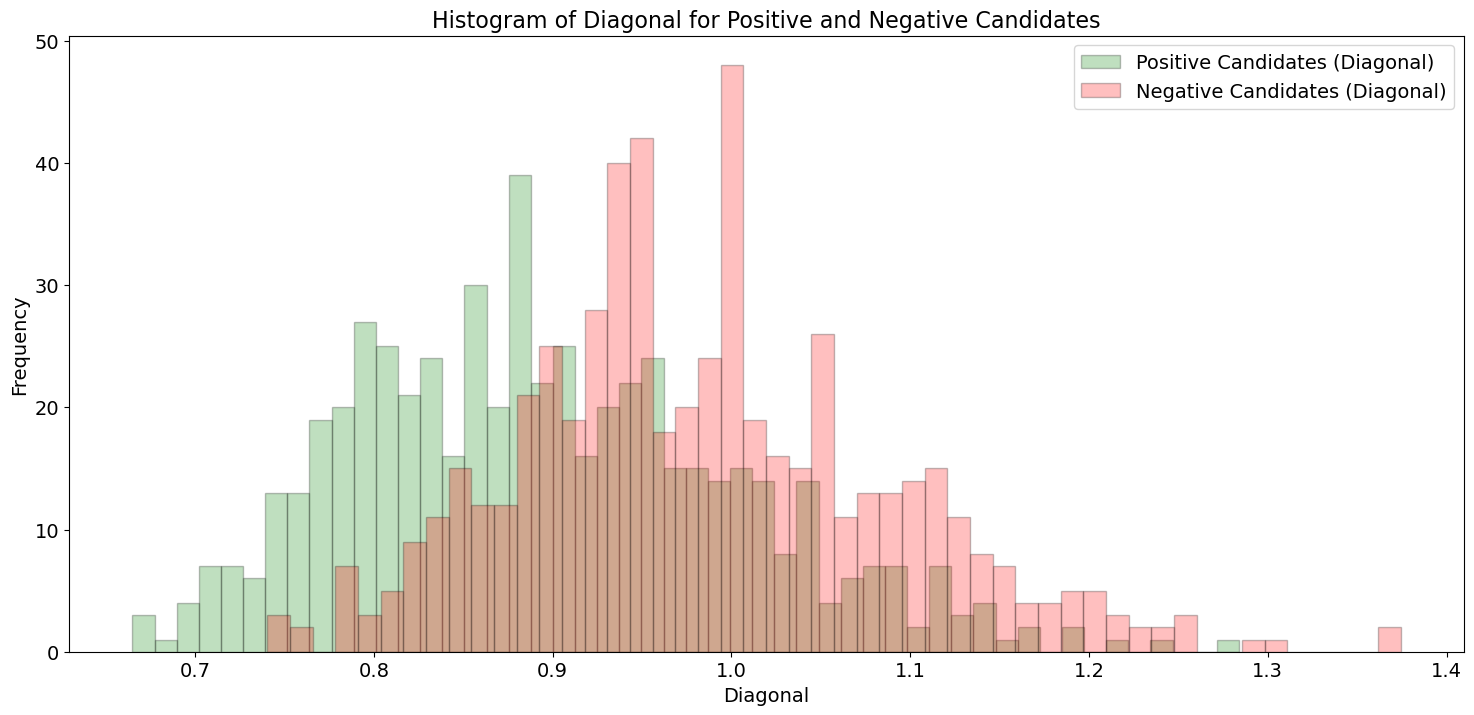

In [33]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["diag"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Diagonal)",
)
_ = plt.hist(
    df_neg["diag"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Diagonal)",
)
plt.legend()
plt.xlabel("Diagonal")
plt.ylabel("Frequency")
plt.title("Histogram of Diagonal for Positive and Negative Candidates")

### Radial Position

Text(0.5, 1.0, 'Histogram of Radial Position for Positive and Negative Candidates')

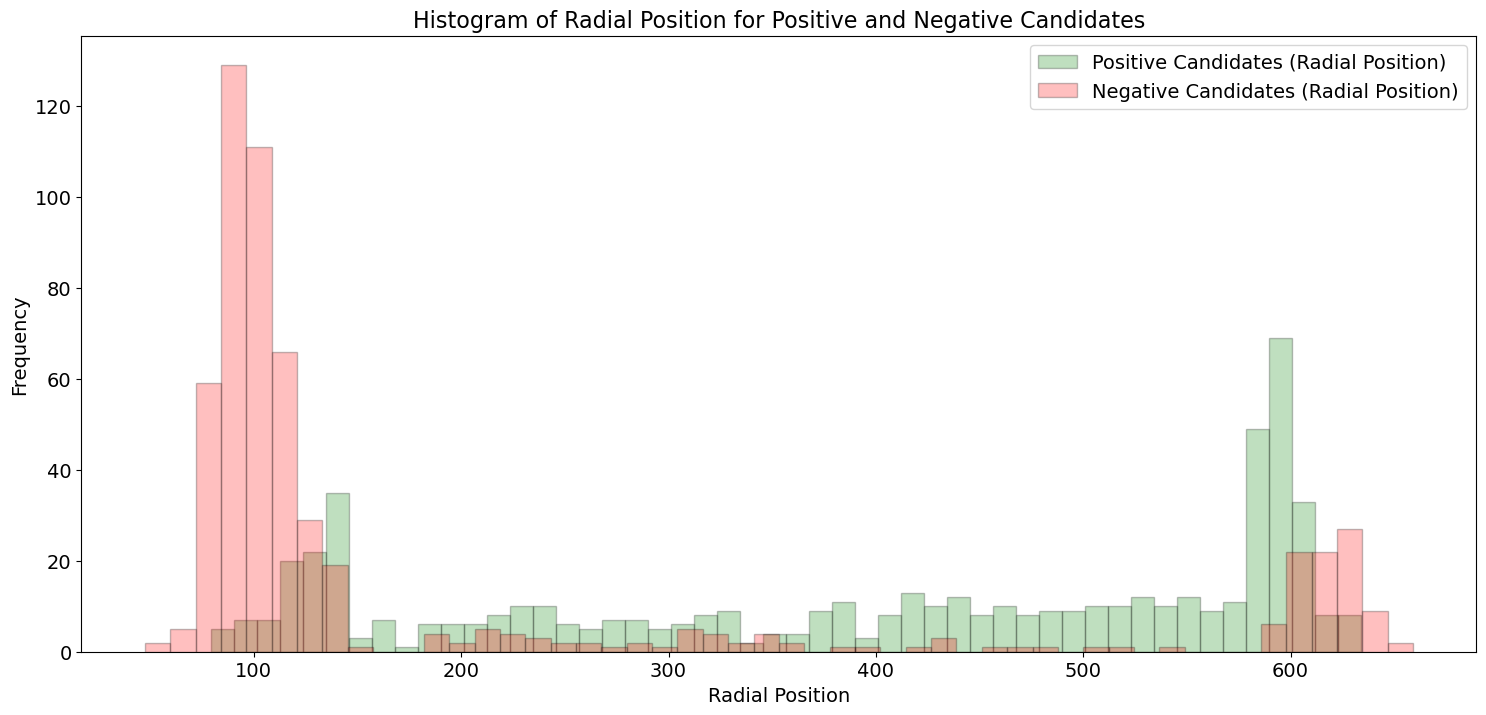

In [36]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["radial_pos"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Radial Position)",
)
_ = plt.hist(
    df_neg["radial_pos"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Radial Position)",
)
plt.legend()
plt.xlabel("Radial Position")
plt.ylabel("Frequency")
plt.title("Histogram of Radial Position for Positive and Negative Candidates")

# Feature Columns

['experiment_number'
       'n_seed_regions', 'z_min', 'z_max', 'z_extent',
       'y_extent', 'x_extent', 
       'metal_threshold',]

# End of Updated Notebook

# Extract the region/seed information to be used for analysis

## Merge rate

Number of unique seed regions: [1 2 3 4 6 8 5]
[0.019, 0.016, 0.013, 0.022, 0.019, 0.016, 0.022, 0.021, 0.02, 0.022, 0.022, 0.02, 0.025, 0.024, 0.022, 0.029, 0.026, 0.025]
Merge rates: [0.019, 0.016, 0.013, 0.022, 0.019, 0.016, 0.022, 0.021, 0.02, 0.022, 0.022, 0.02, 0.025, 0.024, 0.022, 0.029, 0.026, 0.025]


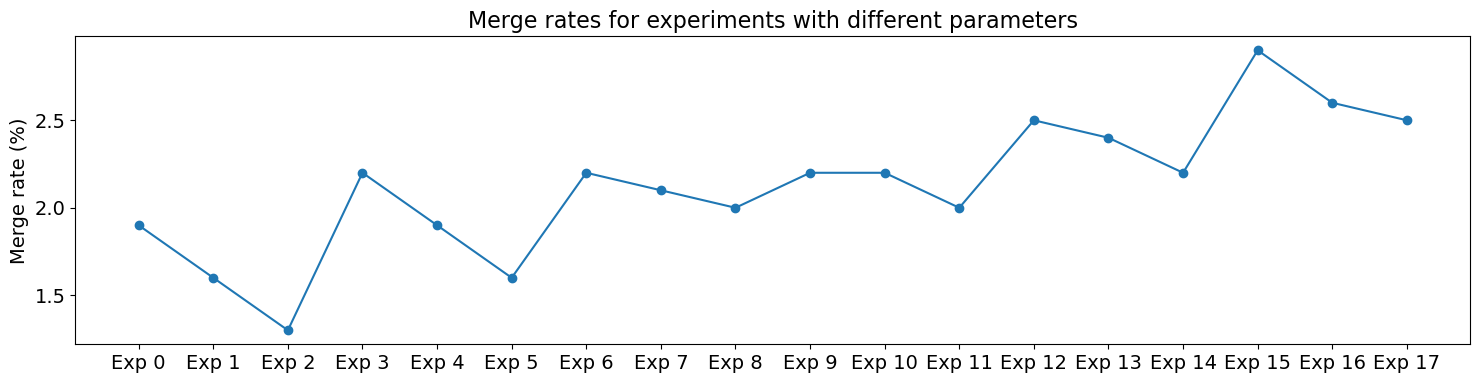

In [ ]:
print(f"Number of unique seed regions: {exp_candidates[2]['n_seed_regions'].unique()}")
merge_rate = []
for n, ec, ep in zip(range(len(exp_candidates)), exp_candidates, exp_params):
    unique_seed_regions = sorted(ec["n_seed_regions"].unique())
    table = []
    for u in unique_seed_regions:
        count = len(ec[ec["n_seed_regions"] == u])
        table.append((int(u), count))
    # print(f"Exp {n}: {table}")
    n_candidates = len(ec)
    n_seed_regions = len(ec[ec["n_seed_regions"] > 1])
    merge_rate.append(round(n_seed_regions / n_candidates, 3))


print(merge_rate)
plt.figure(figsize=(18, 4))
plt.plot(np.array(merge_rate) * 100, marker="o")
plt.title("Merge rates for experiments with different parameters")
plt.ylabel("Merge rate (%)")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
print(f"Merge rates: {merge_rate}")
plt.show()


## Grow ratio distribution

[1.903, 1.609, 1.375, 1.923, 1.679, 1.477, 1.99, 1.718, 1.526, 2.022, 1.739, 1.53, 2.057, 1.763, 1.545, 2.107, 1.783, 1.57]


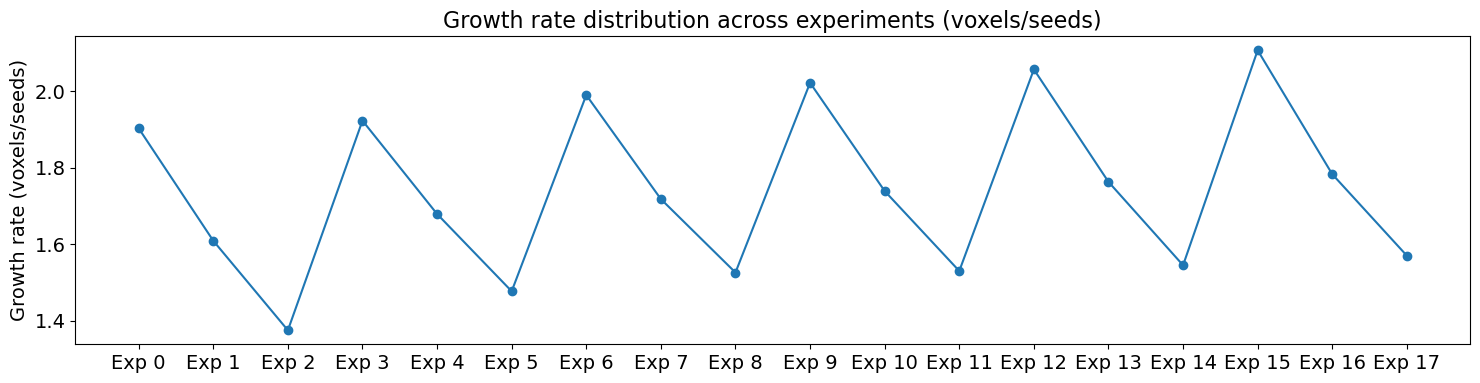

In [ ]:
grow_rate_distribution = []
for n, ec, ep in zip(range(len(exp_candidates)), exp_candidates, exp_params):
    n_voxels = ec["n_voxels"].sum()
    n_seed_total = ec["n_seed_total"].sum()
    grow_rate_distribution.append(float(round(n_voxels / n_seed_total, 3)))

print(grow_rate_distribution)

plt.figure(figsize=(18, 4))
plt.plot(grow_rate_distribution, marker="o")
plt.title("Growth rate distribution across experiments (voxels/seeds)")
plt.ylabel("Growth rate (voxels/seeds)")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
plt.show()

## Large regions

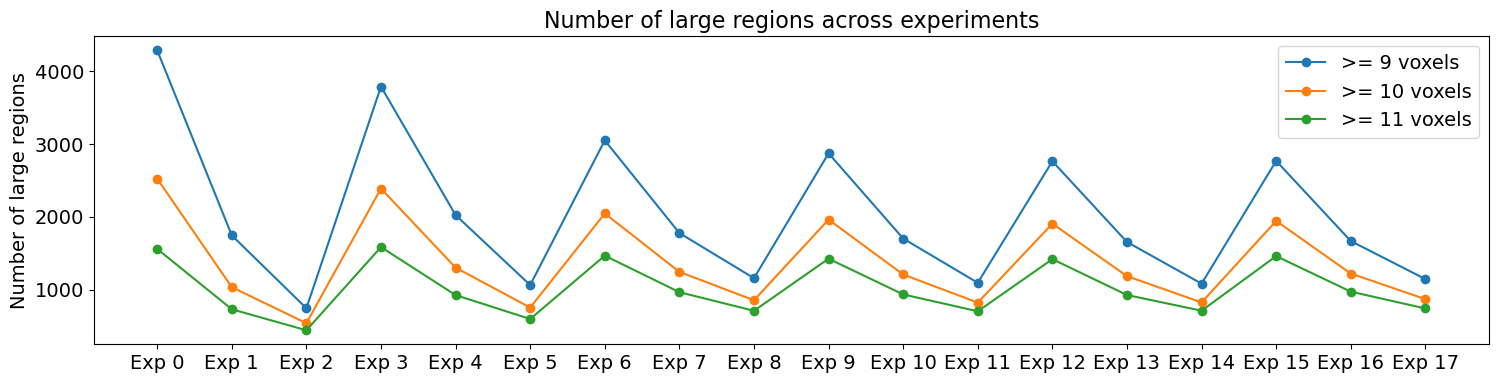

In [ ]:
n_large_thresh = [9, 10, 11]
n_large_regions = [
    [len(ec[ec["n_voxels"] >= n_large]) for ec in exp_candidates]
    for n_large in n_large_thresh
]
plt.figure(figsize=(18, 4))
for n_large, regions in zip(n_large_thresh, n_large_regions):
    plt.plot(regions, marker="o", label=f">= {n_large} voxels")
plt.title("Number of large regions across experiments")
plt.ylabel("Number of large regions")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
plt.legend()
plt.ylabel("Number of large regions")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
# plt.yscale("log")
plt.show()

# Seed stability

In [ ]:
"""n_seed stability analysis across the parameter sweep.

Two axes:
  - window axis  : fixed k_low, vary slab_thickness (5 levels)  -> real robustness
  - k_low axis   : fixed window, vary low_threshold_scale (3 levels) -> control (should be flat)

Tracks are built per volume by union-find clustering of intensity-weighted
centroids within TOL voxels. Distances are bimodal (~0 or 20+), so TOL is not
sensitive.
"""

TOL = 2.0
CSV = "../data/experiments/combined_candidates.csv"
COORDS = ["centroid_z", "centroid_y", "centroid_x"]

df = pd.read_csv(
    CSV,
    usecols=[
        "volume_name",
        "n_seed",
        "n_seed_regions",
        "n_seed_total",
        "n_voxels",
        *COORDS,
        "slab_thickness",
        "low_threshold_scale",
        "experiment_number",
        "radial_pos",
    ],
)
df = df[df["radial_pos"] >= 142]  # filter out non-particles
df = df[df["experiment_number"] < 15]
print(f"Loaded {len(df)} candidates from {df.volume_name.nunique()} volumes.")


class UF:
    def __init__(self, n):
        self.p = list(range(n))

    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[ra] = rb


def build_tracks(sub, level_col):
    """Cluster candidates across the levels of level_col, per volume.
    Returns list of track dicts with per-level n_seed and metadata.
    A track keeps at most one candidate per level (the closest to the
    running cluster if collisions occur)."""
    tracks = []
    for vol, g in sub.groupby("volume_name", sort=False):
        g = g.reset_index(drop=True)
        pts = g[COORDS].values
        uf = UF(len(g))
        tree = cKDTree(pts)
        pairs = tree.query_pairs(TOL)
        for a, b in pairs:
            uf.union(a, b)
        roots = {}
        for i in range(len(g)):
            roots.setdefault(uf.find(i), []).append(i)
        lv = g[level_col].values
        ns = g["n_seed"].values
        nsr = g["n_seed_regions"].values
        for members in roots.values():
            per = {}
            for i in members:
                # if two candidates from same level land in one cluster, keep larger n_seed
                if lv[i] not in per or ns[i] > per[lv[i]][0]:
                    per[lv[i]] = (ns[i], nsr[i])
            seeds = np.array([per[k][0] for k in per])
            regions = np.array([per[k][1] for k in per])
            tracks.append(
                {
                    "vol": vol,
                    "present": len(per),
                    "n_seed_vals": seeds,
                    "n_seed_mean": seeds.mean(),
                    "n_seed_min": seeds.min(),
                    "n_seed_max": seeds.max(),
                    "n_seed_range": seeds.max() - seeds.min(),
                    "n_seed_cv": seeds.std() / seeds.mean()
                    if seeds.mean() > 0
                    else 0.0,
                    "any_merge": bool((regions > 1).any()),
                }
            )
    return tracks


def summarize(tracks, n_levels, label):
    t = pd.DataFrame(tracks)
    tot = len(t)
    print(f"\n===== {label} =====")
    print(f"total tracks (unique blobs): {tot}")
    print("persistence (present in k of %d levels):" % n_levels)
    pc = t.present.value_counts().sort_index()
    for k, v in pc.items():
        print(f"   {k}/{n_levels}: {v:6d}  ({100 * v / tot:5.1f}%)")
    persist_all = (t.present == n_levels).mean()
    print(f"present in ALL {n_levels} levels: {100 * persist_all:.1f}%")

    multi = t[t.present >= 2].copy()
    print(f"\namong tracks present in >=2 levels (n={len(multi)}):")
    for lo, hi, name in [
        (0, 4, "small n_seed_mean<=4"),
        (5, 10, "mid 5-10"),
        (11, 10**9, "large >10"),
    ]:
        s = multi[
            (multi.n_seed_mean >= lo if lo > 0 else True) & (multi.n_seed_mean <= hi)
        ]
        if lo == 0:
            s = multi[multi.n_seed_mean <= hi]
        if len(s) == 0:
            continue
        stable = (s.n_seed_range <= 1).mean()
        print(
            f"   {name:22s} n={len(s):6d}  median CV={s.n_seed_cv.median():.3f}  "
            f"median range={s.n_seed_range.median():.1f}  frac |range|<=1={stable:.3f}"
        )
    # bridge flicker signature: range exactly 1
    flick = (multi.n_seed_range == 1).mean()
    print(f"   fraction with n_seed_range exactly 1 (bridge ±1 flicker): {flick:.3f}")
    return t


Loaded 370474 candidates from 23 volumes.


In [52]:
# ---- window axis (fixed k_low) ----
print("#" * 60)
print("WINDOW AXIS  (fixed k_low, vary slab_thickness over 5 levels)")
print("#" * 60)
win_summaries = {}
for k in sorted(df.low_threshold_scale.unique()):
    sub = df[df.low_threshold_scale == k]
    tr = build_tracks(sub, "slab_thickness")
    win_summaries[k] = summarize(tr, 6, f"window axis @ k_low={k}")


############################################################
WINDOW AXIS  (fixed k_low, vary slab_thickness over 5 levels)
############################################################

===== window axis @ k_low=2.5 =====
total tracks (unique blobs): 73629
persistence (present in k of 6 levels):
   1/6:  47495  ( 64.5%)
   2/6:  14801  ( 20.1%)
   3/6:   5783  (  7.9%)
   4/6:   3083  (  4.2%)
   5/6:   2467  (  3.4%)
present in ALL 6 levels: 0.0%

among tracks present in >=2 levels (n=26134):
   small n_seed_mean<=4   n= 25398  median CV=0.000  median range=0.0  frac |range|<=1=0.992
   mid 5-10               n=   331  median CV=0.126  median range=2.0  frac |range|<=1=0.375
   large >10              n=   154  median CV=0.088  median range=4.0  frac |range|<=1=0.117
   fraction with n_seed_range exactly 1 (bridge ±1 flicker): 0.106

===== window axis @ k_low=2.75 =====
total tracks (unique blobs): 76075
persistence (present in k of 6 levels):
   1/6:  48765  ( 64.1%)
   2/6:  15386  ( 

In [ ]:
# ---- k_low axis (fixed window) ----
print("\n" + "#" * 60)
print("K_LOW AXIS  (fixed window, vary low_threshold_scale over 3 levels)")
print("#" * 60)
for w in sorted(df.slab_thickness.unique()):
    sub = df[df.slab_thickness == w]
    tr = build_tracks(sub, "low_threshold_scale")
    summarize(tr, 3, f"k_low axis @ window={w}")

In [ ]:
2600 / 370000

0.007027027027027027

# END OF NOTEBOOK